# Entrega TP2 - Clasificacion y Ensemble Learning



In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocessing import (
    cargar_dataset,
    obtener_columnas,
    crear_target_binario,
    resumen_faltantes,
    validar_rangos,
    resumen_outliers_iqr,
    limpieza_basica
)

from plots import (
    graficar_faltantes,
    graficar_histogramas,
    graficar_boxplots,
    graficar_categoricas,
    graficar_target_multiclase,
    graficar_target_binario,
    graficar_target_por_grupo,
    graficar_boxplots_por_escuela,
    graficar_correlacion_target_por_escuela,
    graficar_matriz_confusion,
    graficar_curva_roc,
    graficar_curva_pr,
    graficar_f1_vs_lambda,
    graficar_comparacion_estabilidad,
    graficar_boxplot_coeficientes,
    graficar_matriz_confusion_multiclase,
    graficar_roc_multiclase_ovr,
    graficar_pr_multiclase_ovr,
    graficar_comparacion_modelos,
    graficar_f1_por_clase_modelos,
    graficar_importancia_features,
    graficar_curvas_roc_rebalanceo,
    graficar_curvas_pr_rebalanceo,
    graficar_comparacion_rebalanceo,
    graficar_matriz_confusion,
    graficar_learning_curve_rf
)

from utils import (
    mostrar_fragmento_aleatorio,
    resumen_dataset,
    tabla_frecuencias
)

from data_splitting import (
    hacer_split_desde_indices,
    obtener_indices_random_split_estratificado,
    obtener_indices_group_split_por_escuela,
    obtener_indices_temporal_split
)

from metrics import tabla_metricas_binarias

from features import obtener_categorias_fijas

from validation import (
    entrenar_y_evaluar_logistica,
    buscar_mejor_lambda_random_cv,
    buscar_mejor_lambda_group_cv,
    buscar_mejor_lambda_temporal,
    obtener_coeficientes_random_cv,
    obtener_coeficientes_group_cv,
    comparar_estabilidad_coeficientes,
    cross_validar_modelo_group_kfold,
    buscar_mejor_config_random_forest_group_kfold,
    armar_tabla_comparativa_modelos,
    armar_tabla_f1_por_clase_modelos,
    cross_validar_rebalanceo_group_kfold,
    tabla_resultados_rebalanceo,
    entrenar_final_y_evaluar_binario,
    entrenar_final_y_evaluar_multiclase,
    estimar_datos_nuevos_random_forest_multiclase

)

from models import (LDAClassifierManual,
    LogisticRegressionMulticlass,
    RandomForestClassifierManual,)

In [2]:
df = cargar_dataset('../data/raw/rendimiento_estudiantes_dev.csv')
columnas_numericas, columnas_categoricas, target = obtener_columnas()

## 1.1 Análisis exploratorio


In [3]:
df.shape
df.head()
resumen_dataset(df)
mostrar_fragmento_aleatorio(df)

,horas_estudio,asistencia,nota_previa,horas_sueno,participacion,horas_extracurricular,acceso_internet,distancia_escuela_km,nivel_socioeconomico,tamano_clase,escuela,semestre,rendimiento
1962,4.7,81.3,8.8,5.9,4.4,1.3,1,0.6,0.485,26,F,2023-1,Excelente
4302,6.7,78.2,8.6,8.9,5.6,3.7,0,0.9,0.507,24,A,2024-2,Excelente
2784,4.1,81.2,NaN,5.0,5.9,0.1,1,0.6,0.306,32,B,2022-1,Bueno
3221,NaN,79.2,5.9,6.7,3.4,4.0,0,2.2,NaN,37,E,2023-1,Bueno
4685,5.4,86.2,9.6,8.6,9.0,1.1,0,0.3,0.778,21,C,2023-1,Excelente


### Variables numéricas, categóricas y target

In [4]:
columnas_numericas, columnas_categoricas, target

(['horas_estudio',
  'asistencia',
  'nota_previa',
  'horas_sueno',
  'participacion',
  'horas_extracurricular',
  'acceso_internet',
  'distancia_escuela_km',
  'nivel_socioeconomico',
  'tamano_clase'],
 ['escuela', 'semestre'],
 'rendimiento')

Primero veo el tamaño del dataset para ir teniendo una idea, sus primeras filas y un resumen de columnas para ver la estructura del mismo. Identifico que variables son numericas, cuales categoricas y pór ultimo la variable objetivo.


### Valores faltantes

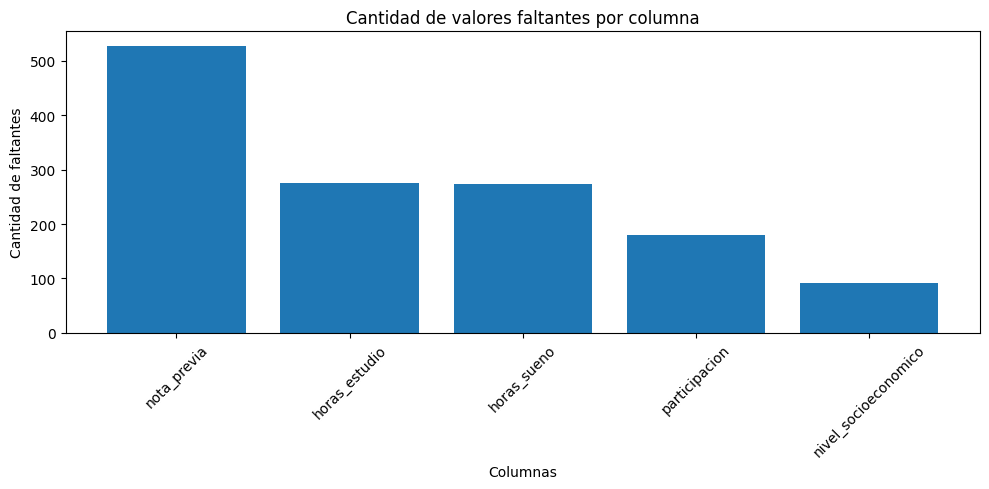

In [5]:
resumen_faltantes(df)
graficar_faltantes(df)

Vemos que hay valores faltantes en 5 variables del dataset. La mas afectada, nota previa, luego horas de estudio y horas sueno que tienen casi la misma cantidad de faltantes, participacion y nivel socioeconomico tambien tienen faltantes pero menos que las anteriores. Las otras columnas no tienen valores ausentes.


### Distribución de variables numéricas

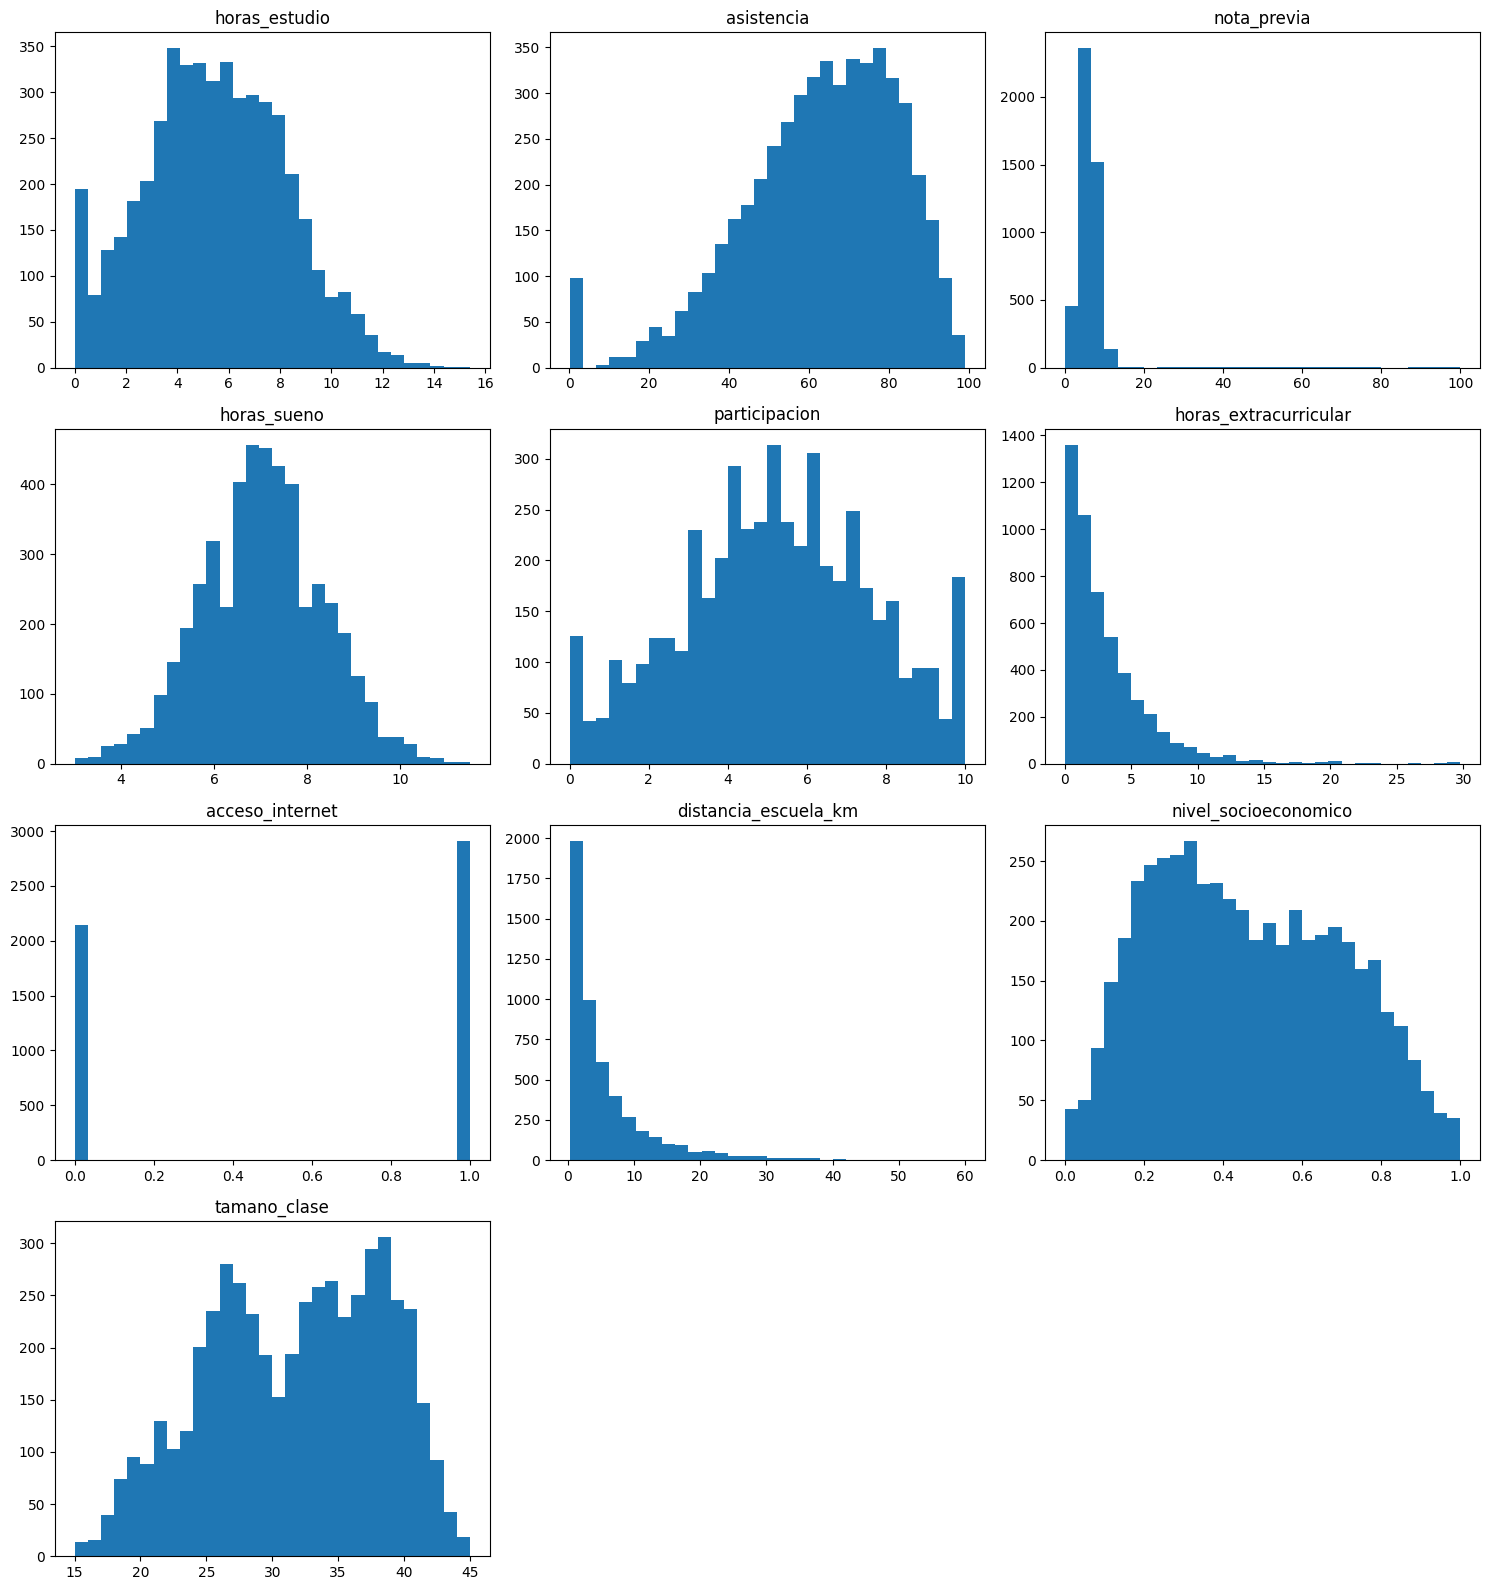

In [6]:
graficar_histogramas(df, columnas_numericas)

## Distribución de variables numéricas
Con los histogramas se ve que claramente no todas las variables numericas siguen misma distribucion.
- horas_estudio se concentra en valores intermedios, con una leve asimetría hacia la derecha.
- asistencia se concentra en valores relativamente altos.
- nota_previa se concentra mucho en valores bajos/intermedios, pero tambien aparecen algunos muy altos que llaman la atencion y podrian ser errores.
- horas_sueno tiene forma de campana con media en 7.
- participacion se distribuye en casi todo su rango, pero mas en valores medios.
- horas_extracurricular presenta mucha asimetria positiva, la mayoria de estudiantes dedica pocas horas.
- distancia_escuela_km tambien presenta asimetria positiva, con la mayoria de estudiantes cerca.
- nivel_socioeconomico toma valores entre 0 y 1 y se distribuye de manera relativamente extendida en ese intervalo, quizas se concentran mas alrededor de 0.2.
- tamano_clase no es uniforme ni campana, se ve que hay varios grupos.
- acceso internet es binaria entonces solo vemos la frecuencia de las cateogrias 0 y 1 , y hay mas 1s.


### Outliers

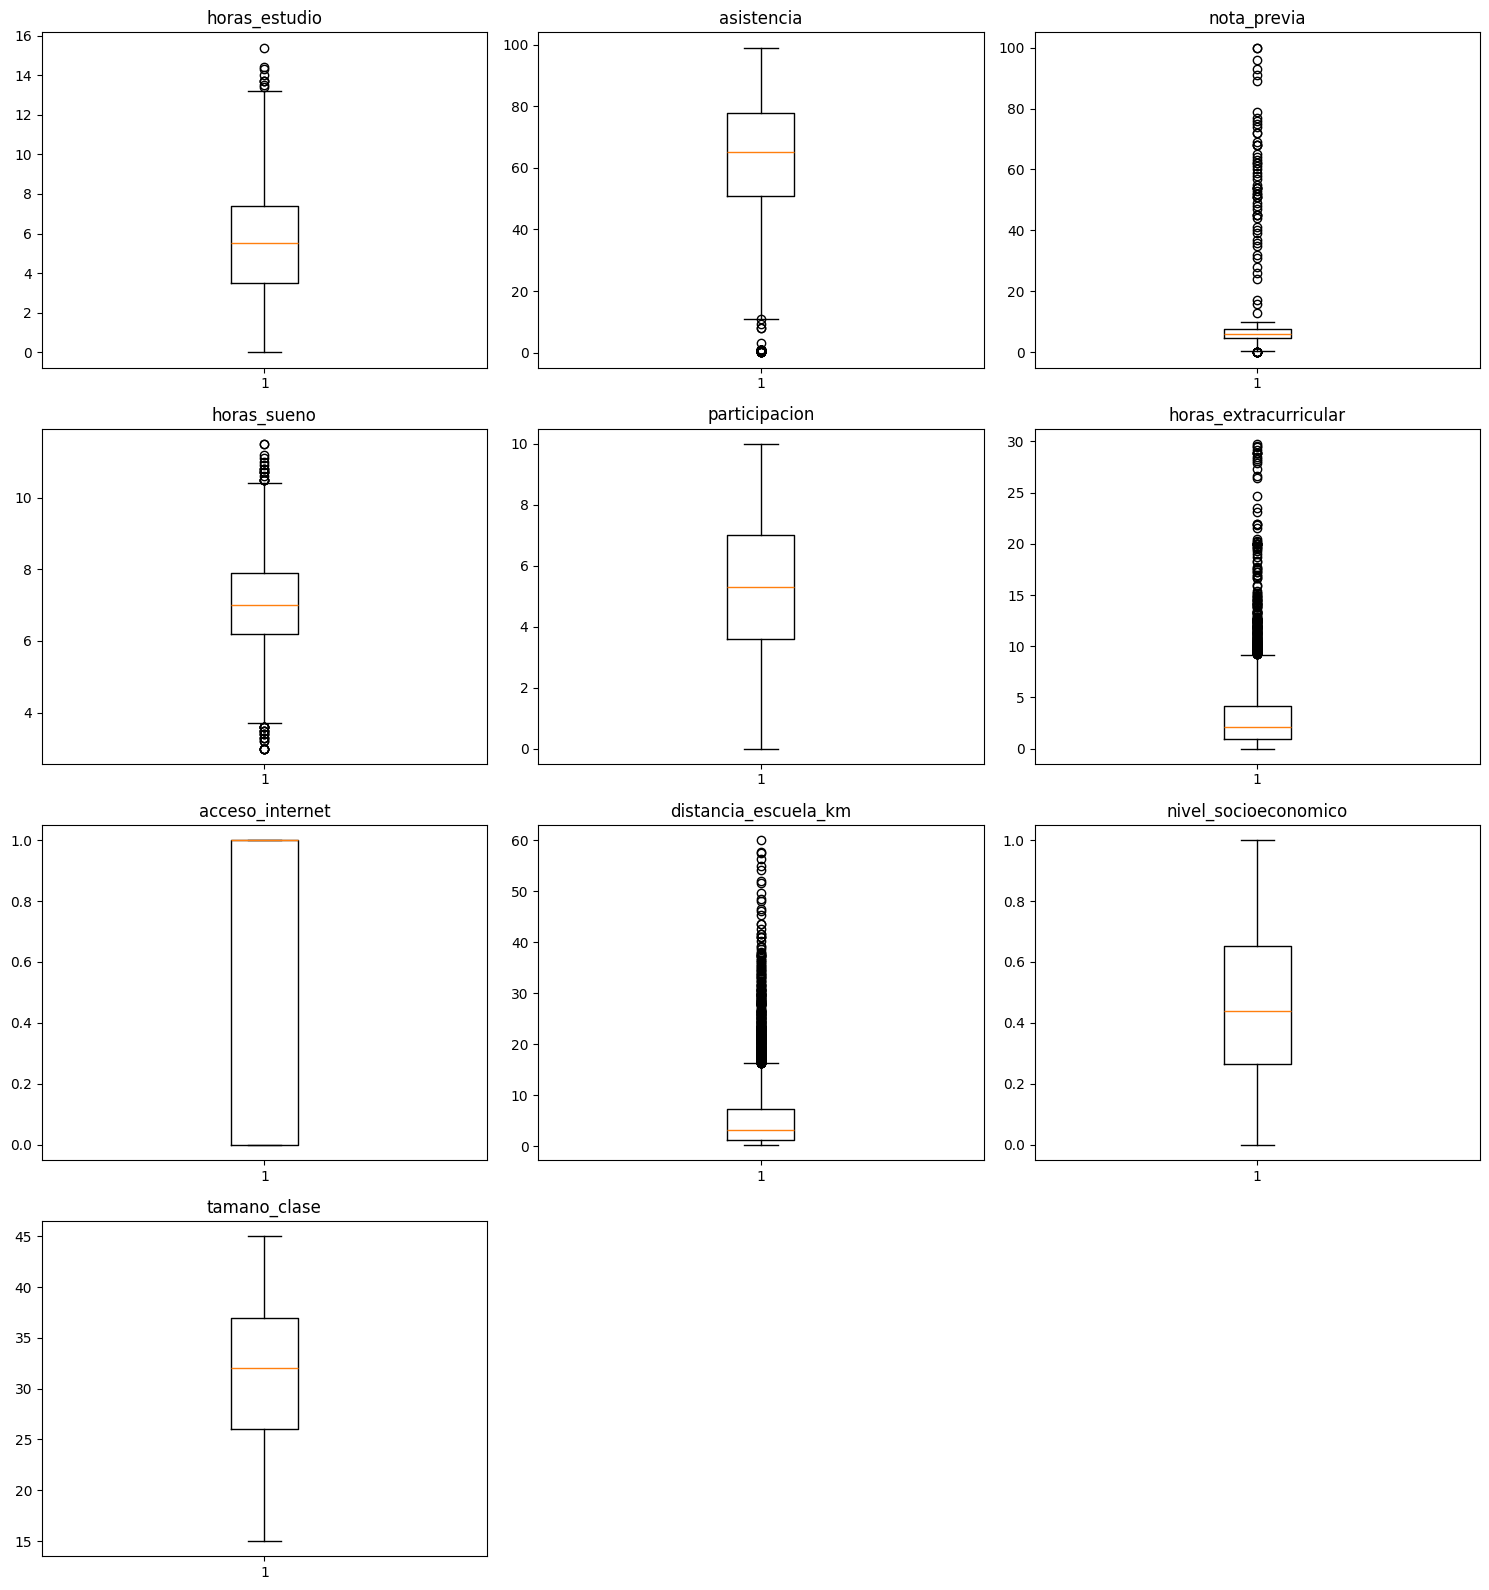

,columna,q1,q3,iqr,limite_inferior,limite_superior,cantidad_outliers
7,distancia_escuela_km,1.300,7.300,6.000,-7.700,16.30,388
5,horas_extracurricular,0.900,4.200,3.300,-4.050,9.15,256
1,asistencia,51.000,77.800,26.800,10.800,118.00,102
2,nota_previa,4.600,7.500,2.900,0.250,11.85,70
3,horas_sueno,6.200,7.900,1.700,3.650,10.45,43
0,horas_estudio,3.500,7.400,3.900,-2.350,13.25,9
4,participacion,3.600,7.000,3.400,-1.500,12.10,0
6,acceso_internet,0.000,1.000,1.000,-1.500,2.50,0
8,nivel_socioeconomico,0.265,0.651,0.386,-0.314,1.23,0
9,tamano_clase,26.000,37.000,11.000,9.500,53.50,0


In [7]:
graficar_boxplots(df, columnas_numericas)
resumen_outliers_iqr(df, columnas_numericas)

Hice boxplots y use el criterio del rango Inter cuartilico, veo que distancia_escuela_km y horas_extracurricular son las variables con mas outliers, ambas tienen sentido por las distribuciones vistas antes, que tenian fuerte asimetria positiva y colas largas.
En asistencia, nota_previa, horas_sueno y en menor medida en horas_estudio aparecen outliers tambien. En nota previa vemos valores extremadamentes altos que no resultan consistentes con la escala esperada de la variable, voy a revisar esto cuando preprocese los datos.
Luego participacion, nivel_socioeconomico y tamano_clase no presentan outliers, acceso_internet al ser una variable binaria , el analisis del boxplot no nos da mucha info. 
Por ahora, el hecho que haya outliers no me parece que implique que haya que eliminarlos, en algunos casos pueden ser cosas reales y en otros pueden ser errores. 
Si hay que prestarle atencion a nota previa, ya que se nos dice que hay que medirlo en una escala de 0 a 10, pero en los graficos aprecene valores muy superiores.

### Variables categóricas

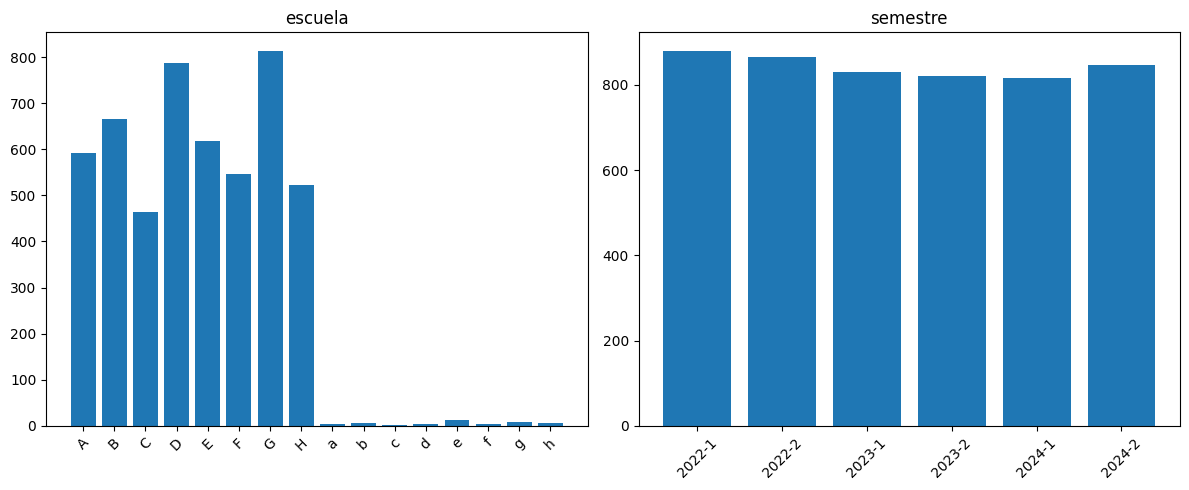

,frecuencia,porcentaje
semestre,,
2022-1,879,17.378410
2022-2,866,17.121392
2024-2,847,16.745749
2023-1,831,16.429419
2023-2,820,16.211941
2024-1,815,16.113088


In [8]:
graficar_categoricas(df, columnas_categoricas)
tabla_frecuencias(df, 'escuela')
tabla_frecuencias(df, 'semestre')

## Variables categóricas
Veo las variables categoricas y observo que escuela tiene posiblemente inconsistencias al codificarse, hay algunas en mayuscula y otras en minuscula, por mas que refieran a la misma escuela. Luego si tambien veo que la cantidad de observaciones por escuela no es uniforme pero tampoco hay diferencias abismales. Por su parte, la variable semestre tiene una distribucion bastante equlibrada entre los 6 periodos.

### Distribución del target multiclase

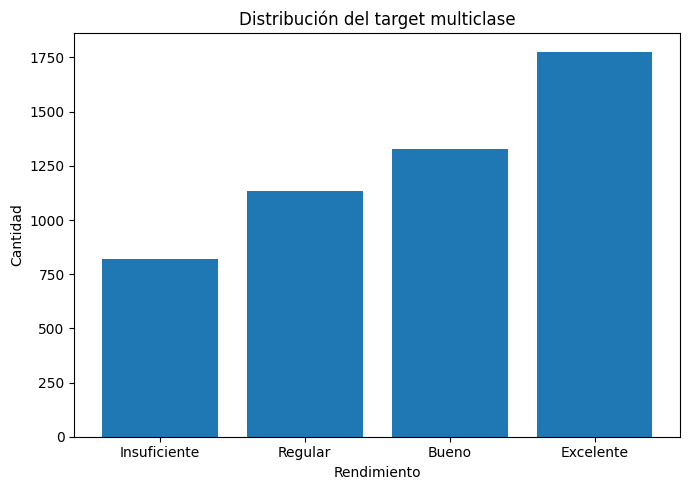

In [9]:
tabla_frecuencias(df, 'rendimiento')
graficar_target_multiclase(df)

## Distribución del target multiclase
La variable objetivo en multiclase tiene desbalance aunque no severo. La mas frecuente es Excelente, luego bueno, seguida por regular y por ultimo insuficiente. Cuando evaluemos modelos, por este desbalance vamos a tener que considerar metricas por clase.

### Distribución del target binario

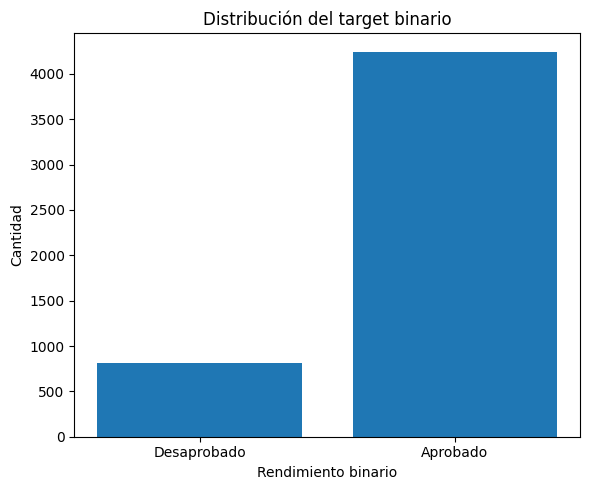

In [10]:
df_bin = crear_target_binario(df)
tabla_frecuencias(df_bin, 'rendimiento_binario')
graficar_target_binario(df_bin)

## Distribución del target binario
Cuando vemos la variable objetivo en binaria vemos claramente el desbalance entre aprobado que es mucho mayor a desaprobado. Hay que tener en cuenta este desbalacne luego para el entrenamiento y evaluacion de modelos .

## 1.2 Estructura de grupo del dataset


In [11]:
df_clean = limpieza_basica(df)
validar_rangos(df_clean)

,columna,min_esperado,max_esperado,cantidad_fuera_de_rango
0,asistencia,0,100.0,0
1,nota_previa,0,10.0,0
2,horas_sueno,0,24.0,0
3,participacion,0,10.0,0
4,nivel_socioeconomico,0,1.0,0
5,acceso_internet,0,1.0,0
6,distancia_escuela_km,0,inf,0
7,tamano_clase,0,inf,0
8,horas_estudio,0,inf,0
9,horas_extracurricular,0,inf,0


Hago una limpieza basica antes de analizar por grupos. Se normalizo la codificacion de escuela, se corrigieron inconsistencias en variables numericas (nota y asistencia) y se creo la version binaria de la variable objetivo..

Ahora si vamos a adentrarnos en como varian las features entre escuelas. Decidi no mostrar absolutamente todas las features porque iban a ser muchos graficos y me parece que seleccione las mas representativas que nos sirven. Vamos a ver horas estudio, asistencia, nota previa, nivel socioeconomico y tamano clase. Los boxplots nos van a dejar ver las diferencias en nivel, dispersion y outliers.

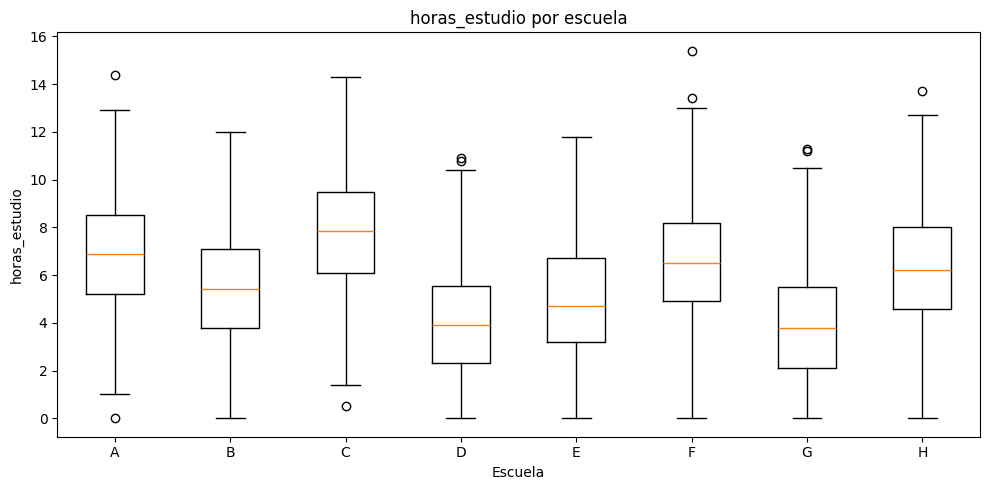

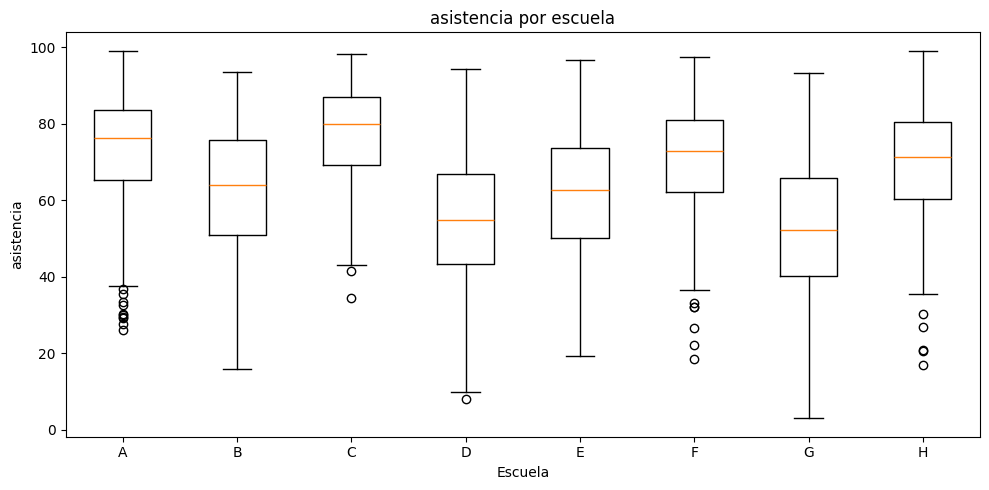

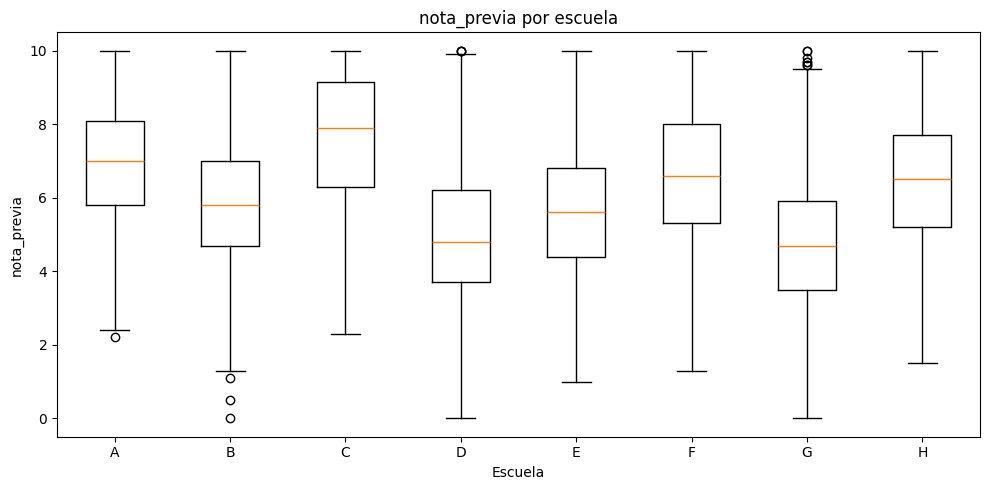

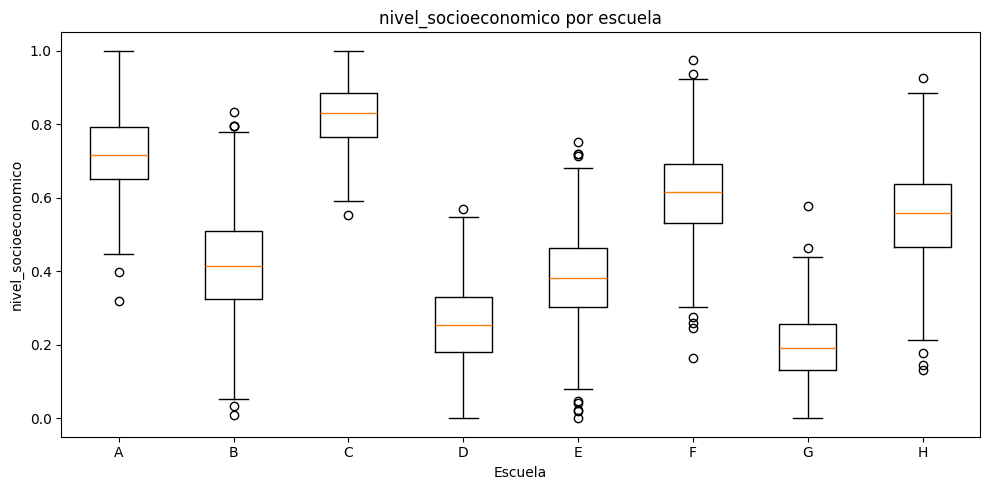

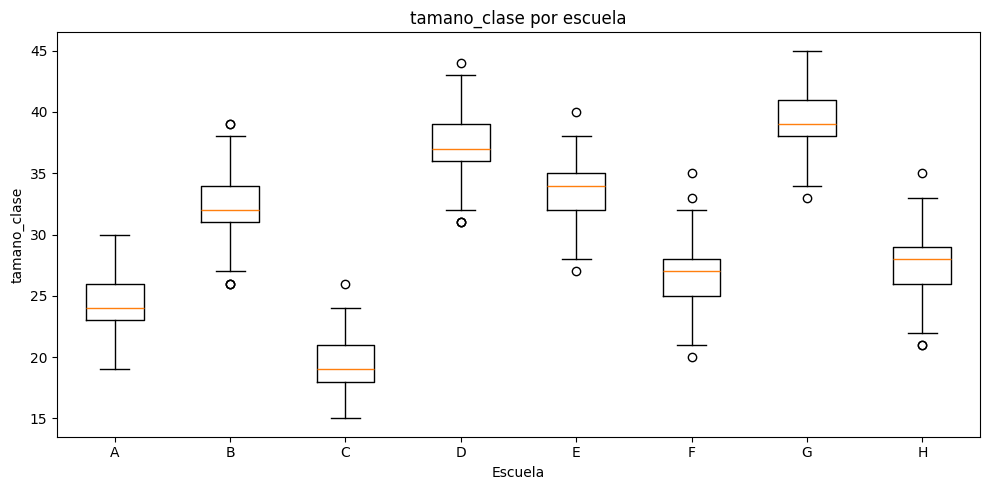

In [12]:
features_grupo = [
    'horas_estudio',
    'asistencia',
    'nota_previa',
    'nivel_socioeconomico',
    'tamano_clase'
]

graficar_boxplots_por_escuela(df_clean, features_grupo)

En horas estudio hay medianas mas altas en las escuelas C, F y H, mientras que D y G tienen valores tipicos mas bajos. Vemos que la dedicacion a estudiar no se distribuye de manera homogenea en las diferentes escuelas. En asistencia y nota previa es parecido, las escuelas A, C, F y H tienen medianas mas altas, D y G tienen niveles mas bajos, vemos que el perfil de estudiante varia segun la escuela. Si vemos diferencias bien marcadas en nivel socioeconomico, las escuelas C y A tienen los valores mas altos y luego D y G tienen considerablemente menores valores. El ultimo boxplot el de tamano clase tambien muestra muchas diferencias entre escuelas, con poca dispersi0on dentro de cada una. Vemos que el tamano del aula es algo bastante propio de cada escuela.

Ya note muchas diferencias entre escuelas, esto justifica claramente luego partir por grupo mas adelante, porque un split aleatorio deja mezcladas muchas observaciones de escuelas que pueden diferir mucho.

### ¿Cómo varía la proporción de clases entre escuelas?

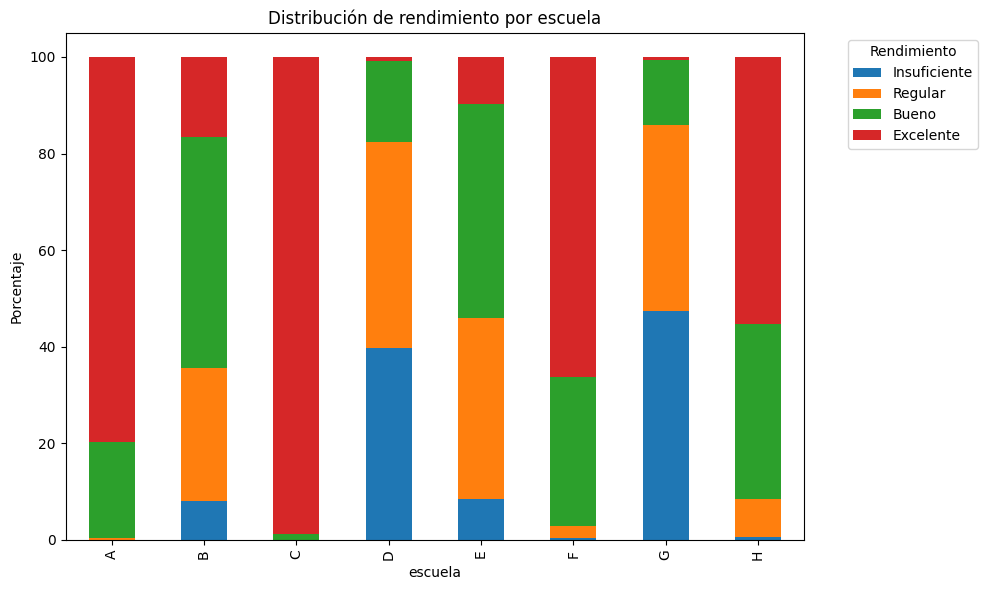

In [13]:
pd.crosstab(df_clean['escuela'], df_clean['rendimiento'], normalize='index') * 100
graficar_target_por_grupo(df_clean, 'escuela')

La distribución de la variable objetivo cambia mucho entre escuelas. Las escuelas A, C, F y H presentan proporcion muy alta de categorias bueno y excelente, y la D y G tienen mucho mas Insuficiente y regular. La escuela no solo afecta la distribucion de las features, sino tambien de la variable objetivo.

### ¿Cómo varía la proporción de clases entre semestres?

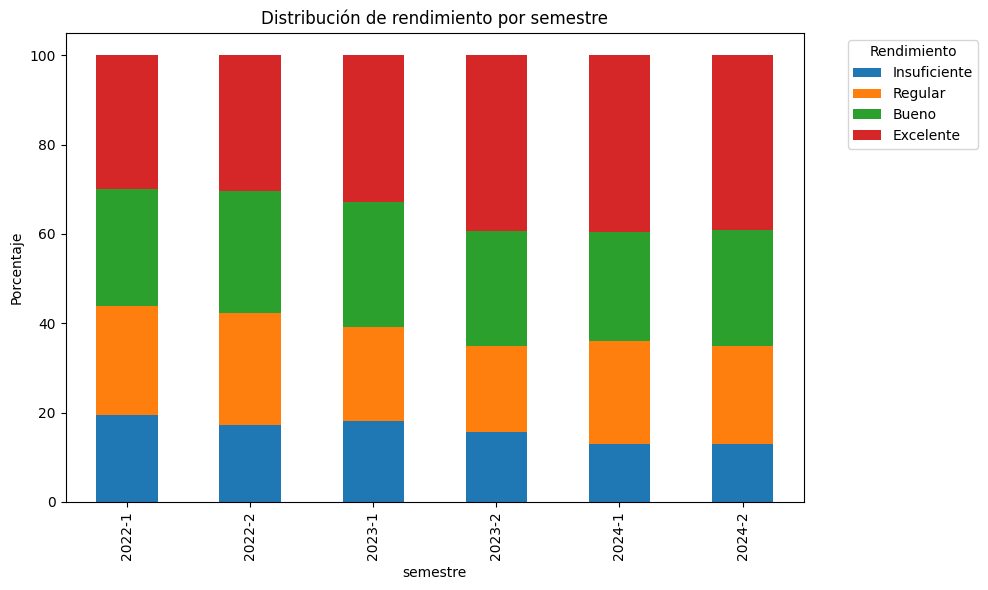

In [14]:
pd.crosstab(df_clean['semestre'], df_clean['rendimiento'], normalize='index') * 100
graficar_target_por_grupo(df_clean, 'semestre')

A diferencia de lo que pasa entre escuelas, esta distribucion es mucho mas estable, no cambian de forma abrupta entre semestres y se mantienen similar. Se pueden ver que a partir del segundo semestre de 2023 hay un poco mas de excelentes y menos insuficientes, pero no muchos mas cambios.

### ¿Cambia la correlación entre las features y el target según la escuela?

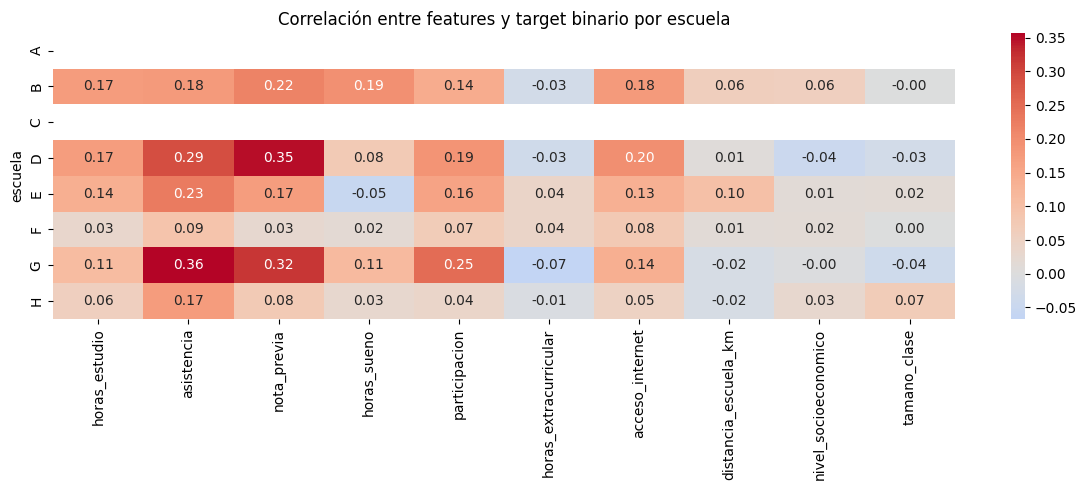

In [15]:
graficar_correlacion_target_por_escuela(df_clean, columnas_numericas)

La relacion entre las features numericas y el target binario cambia con las escuelas. 
En general nota previa, asistencia, participacion y horas estudio (en menor medida) muestran correlaciones positivas con el rendimiento, variando que tanta correlacion segun la escuela. En cambio horas extracurricular, distancia escuela km, nivel socioeconomico y tamano clase muestran correlaciones mas debiles, inestables, incluso cambian de signo entre escuelas. Vemos que la relacion de estas variables con el rendimiento depende mas del contexto de cada escuela. En la escuela A y C no se puede calcular la correlacion porque el target binario no presenta variacion suficiente, practicamente todos los casos van a una clase.
Esto indica que cambia las distribuciones de las features entre escuelas, lo cual ya sabiamos, y tambien la forma en la que se relacionan esas features con el target, si entrenamos un modelo con ciertas escuelas en particular podria no generalizar bien.

Del analisis me llevo que las escuelas difieren en distribucion de features y de variable objetivo, las relaciones entre las variables y el rendimiento tambien varia entre escuelas, no hay mucha diferencia entre semestres por lo que la principal fuente de heterogeneidad del dataset parece estar dada por la variable escuela.

## 1.3 Limpieza y preprocesamiento


Si bien la limpieza basica en si se hizo en una celda de la parte 1.2, aca fundamento bien las decisiones.
En la limpieza basica: se normalizó la variable escuela para evitar duplicaciones por diferencias entre mayúsculas y minúsculas, se corrigió nota_previa cuando aparecía cargada en escala 0 a 100, llevándola a la escala esperada de 0 a 10, se corrigió asistencia cuando aparecía expresada como proporción en lugar de porcentaje y se creó la variable rendimiento_binario, que será utilizada en la parte de clasificación binaria.

Ahora bien, no ignore los valores faltantes, en esta parte si mire cuantos eran y de que variables era, vimos que habia en nota_previa, horas_estudio, horas_sueno, participacion y nivel_socioeconomico. No hago en esta parte una imputacion ya que conviene hacerla mas adelante dentro de cada conjunto de train para evitar data leakage, pero ya sabemos que estas variables van a necesitar de eso.

En cuanto a los outliers que vimos en un par de features como distancia_escuela_km, horas_extracurricular, asistencia y horas_sueno, en general no voy a eliminarlos asi de forma automatica ya que considero que pueden ser datos reales. Si en el caso de nota previa modifique las notas para que queden todas en la misma escala, no eran simples outliers.

Para el modelado voy a tener que tomar decisiones mas adelante. Por ejemplo los modelos que no admitan categorias de forma directa, necesitaran de alguna codificacion para la variable escuela, mientras que las variables numericas quizas requieran escalado en los modelos sensibles a la magnitud de features, al igual que la imputacion que mencione, ese escalado tiene que ser con los datos de train para no lekear data.


In [16]:
validar_rangos(df_clean)

,columna,min_esperado,max_esperado,cantidad_fuera_de_rango
0,asistencia,0,100.0,0
1,nota_previa,0,10.0,0
2,horas_sueno,0,24.0,0
3,participacion,0,10.0,0
4,nivel_socioeconomico,0,1.0,0
5,acceso_internet,0,1.0,0
6,distancia_escuela_km,0,inf,0
7,tamano_clase,0,inf,0
8,horas_estudio,0,inf,0
9,horas_extracurricular,0,inf,0


### Guardado del dataset limpio

In [17]:
df_clean.to_csv('../data/processed/rendimiento_estudiantes_dev_clean.csv', index=False)

# 2. Clasificación Binaria y Estrategias de Splitting


**Aclaracion importante:** en esta clasificacion binaria la clase positiva corresponde a la etiqueta 1, a estudiantes con rendimiento no insuficiente, es decir los aprobados. Entonces precision, recall, F1, ROC y PR se ven respecto a esta clase, a la de aprobados. Sigue siendo valida la comparacion entre las estrategias de splitting per olos resultados no se centran en la clase minoritaria que es Insuficiente, desaprobados. Importante aclarar esto porque en el punto 4 cambia.

In [18]:
df_bin = cargar_dataset('../data/processed/rendimiento_estudiantes_dev_clean.csv')

if 'rendimiento_binario' not in df_bin.columns:
    df_bin = crear_target_binario(df_bin)

df_bin = df_bin.reset_index(drop=True)

columnas_numericas, columnas_categoricas, target = obtener_columnas()

categorias_fijas = obtener_categorias_fijas(df_bin, columnas_categoricas)

df_bin.shape

(5058, 14)

## 2.1 Evaluación con tres estrategias de partición
Lo primero que hago es entrenar una logistic regression con L2 y la evaluo de 3 formas distintas: Random split estratificado 80/20, group split por escuela, y temporal split (semestres). Para cada uno de estos muestro matriz de confusion, accuracy, precision, recall, f1 score, la curva ROC y AUC ROC, la curva Precision Recall y AUC-PR.
Uso valores de learning rate, iteraciones, threshold y lambda base arbitrarios que funcionaron normal.



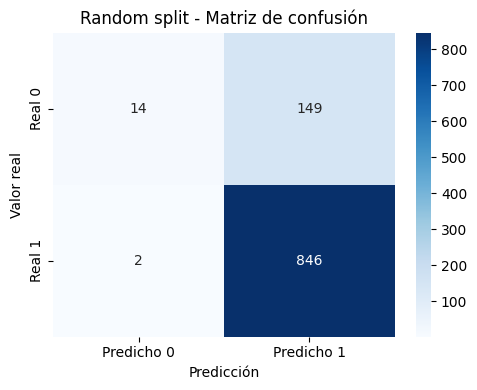

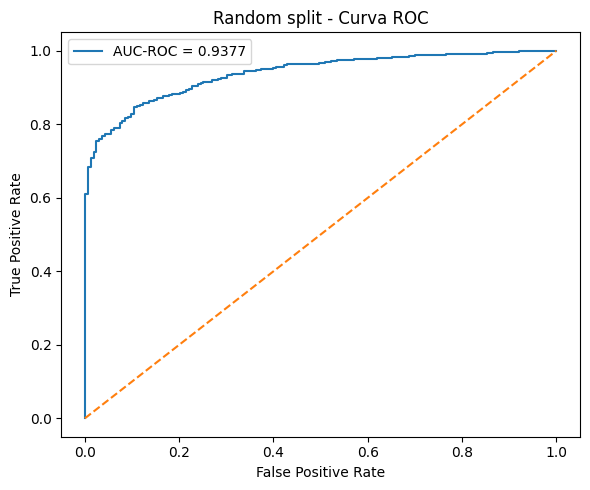

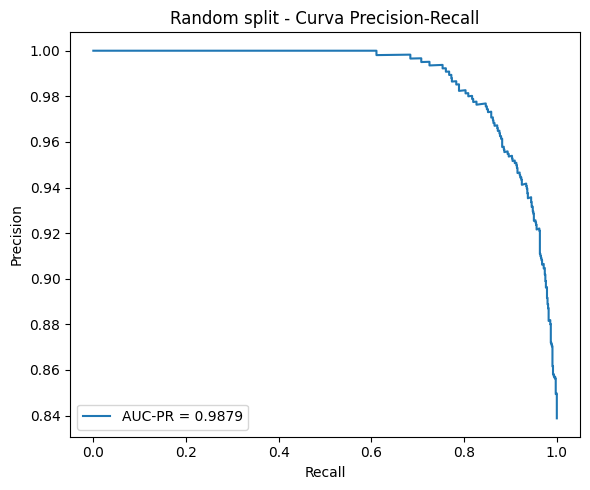

,estrategia,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Random split,0.850643,0.850251,0.997642,0.918068,0.93771,0.987923


In [19]:
learning_rate = 0.01
n_iter = 6000
threshold = 0.5
lambda_base = 0.1

train_idx_random, val_idx_random = obtener_indices_random_split_estratificado(
    df_bin,
    target_col='rendimiento_binario',
    test_size=0.2,
    random_state=42
)

df_train_random, df_val_random = hacer_split_desde_indices(df_bin, train_idx_random, val_idx_random)

resultado_random = entrenar_y_evaluar_logistica(
    df_train_random,
    df_val_random,
    columnas_numericas,
    columnas_categoricas,
    lambda_reg=lambda_base,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)



graficar_matriz_confusion(resultado_random['matriz_confusion'], 'Random split - Matriz de confusión')
graficar_curva_roc(resultado_random['fpr'], resultado_random['tpr'], resultado_random['auc_roc'], 'Random split - Curva ROC')
graficar_curva_pr(resultado_random['recall_curve'], resultado_random['precision_curve'], resultado_random['auc_pr'], 'Random split - Curva Precision-Recall')

tabla_metricas_binarias(resultado_random, estrategia='Random split')

### Random split estratificado
Con el split aleatorio estratificado 80/20, el desempeno de la logistic regression es muy bueno, los resultados son estos:
- Accuracy = 0.851
- Precision = 0.850
- Recall = 0.998
- F1-score = 0.918
- AUC-ROC = 0.938
- AUC-PR = 0.988

Ademas, la matriz de confusion nos dice que el modelo clasifica casi a la perfeccion a los casos postivos que serian los aprobados (muchos verdaderos positivos y pocos falsos negativos), por esto recall alto. Pero por el otro lado vemos una cantidad significativa de falsos positivos, muchos casos reales desaprobados (caso 0), que fueron clasificados como clase 1 (aprobados). El rendimiento general parece muy bueno, pero hay que tener en cuenta que a este modelo le cuesta bien distinguir la clase minoritaria.

Las curvas ROC y Precision Recall muestran una muy buena separacio de clases, AUC ROC y AUC PR altos. Hay que interpretar esto igual, ya que el random split mezcla datos de las mismas escuelas en entrenamiento y validacion, lo que puede dar una estimacion muy optimista de la performance real.

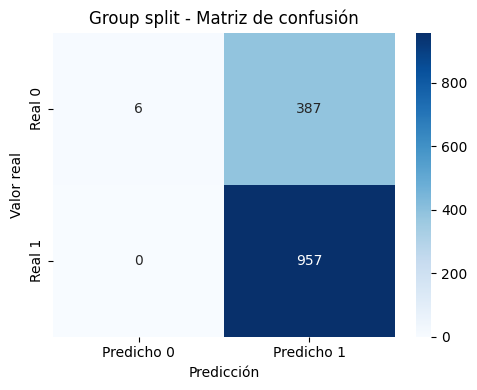

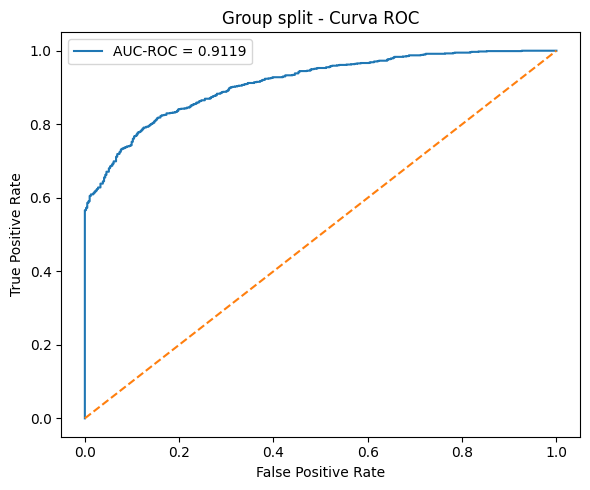

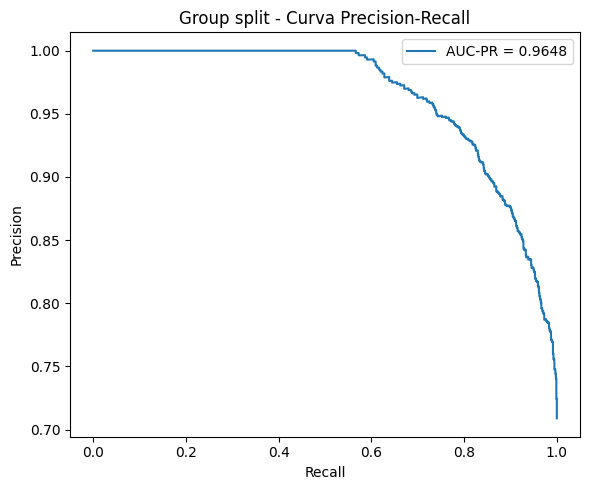

,estrategia,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Group split,0.713333,0.712054,1.0,0.831812,0.911899,0.964814


In [20]:
escuelas_validacion = ['G', 'H']

train_idx_group, val_idx_group = obtener_indices_group_split_por_escuela(
    df_bin,
    escuelas_validacion=escuelas_validacion
)

df_train_group, df_val_group = hacer_split_desde_indices(df_bin, train_idx_group, val_idx_group)

resultado_group = entrenar_y_evaluar_logistica(
    df_train_group,
    df_val_group,
    columnas_numericas,
    columnas_categoricas,
    lambda_reg=lambda_base,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)


graficar_matriz_confusion(resultado_group['matriz_confusion'], 'Group split - Matriz de confusión')
graficar_curva_roc(resultado_group['fpr'], resultado_group['tpr'], resultado_group['auc_roc'], 'Group split - Curva ROC')
graficar_curva_pr(resultado_group['recall_curve'], resultado_group['precision_curve'], resultado_group['auc_pr'], 'Group split - Curva Precision-Recall')

tabla_metricas_binarias(resultado_group, estrategia='Group split')

### Group split por escuela
Cuando la validacion se hace sobre escuelas que no se vieron en training, el desempeno si que empeora respecto del random split, estos son los resultados:
- Accuracy = 0.713
- Precision = 0.712
- Recall = 1.000
- F1-score = 0.832
- AUC-ROC = 0.912
- AUC-PR = 0.965

En la matriz de confusion se ve que el modelo clasifica casi todos los casos como positivos. Esto da un recall perfecta ya que no hay falsos negativos, pero obviamente hay gran cantidad de falsos positivos, vamos a clasificar como aprobados a muchos desaprobados.

Las curvas ROC y Precision Recall muestran valores relativamente altos, sin embargo el desempeno al usar un umbral fijo es claramente peor que el random split. La capacidad del modelo para identificar la clase negativa es bajisima.

Estos resultados me hacen sentido con lo que vimos en el analisis exploratorio, las escuelas tienen muchas diferencias en features y en la distribucion del target, quizas validar sobre escuelas no vistas es muy exigente, puede ser realista igualmente, si se quiere generalizar a escuelas nuevas que lleguen.

Semestres de entrenamiento: ['2022-1', '2022-2', '2023-1', '2023-2', '2024-1']
Semestre de validación: 2024-2


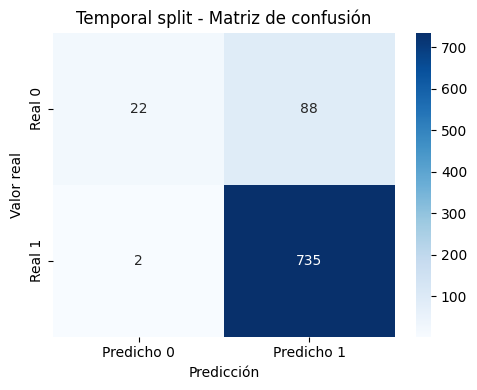

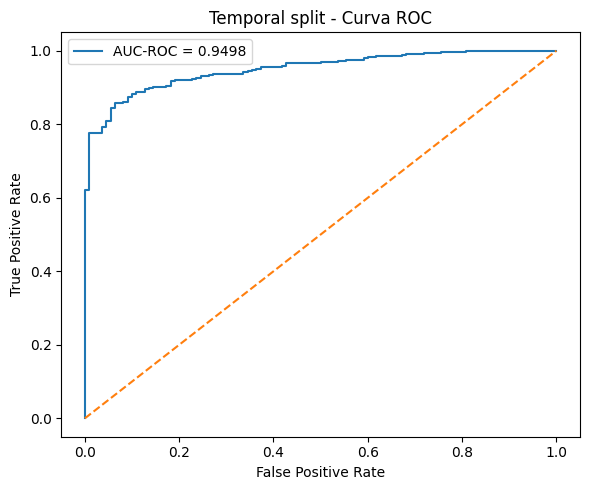

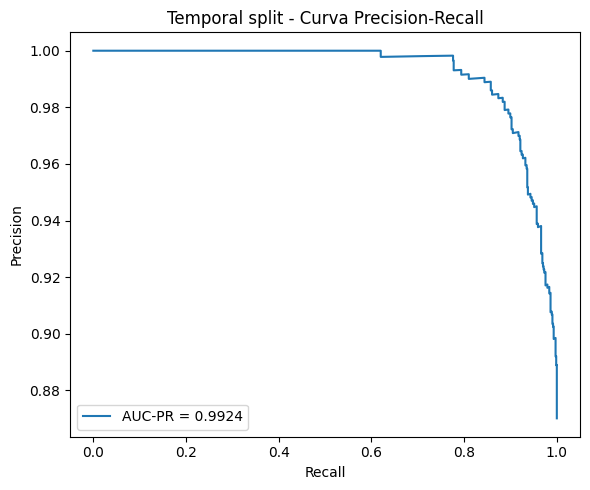

,estrategia,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Temporal split,0.893743,0.893074,0.997286,0.942308,0.949759,0.992403


In [21]:
train_idx_temp, val_idx_temp, semestres_train, semestre_val = obtener_indices_temporal_split(df_bin)

df_train_temp, df_val_temp = hacer_split_desde_indices(df_bin, train_idx_temp, val_idx_temp)

print('Semestres de entrenamiento:', semestres_train)
print('Semestre de validación:', semestre_val)

resultado_temp = entrenar_y_evaluar_logistica(
    df_train_temp,
    df_val_temp,
    columnas_numericas,
    columnas_categoricas,
    lambda_reg=lambda_base,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)


graficar_matriz_confusion(resultado_temp['matriz_confusion'], 'Temporal split - Matriz de confusión')
graficar_curva_roc(resultado_temp['fpr'], resultado_temp['tpr'], resultado_temp['auc_roc'], 'Temporal split - Curva ROC')
graficar_curva_pr(resultado_temp['recall_curve'], resultado_temp['precision_curve'], resultado_temp['auc_pr'], 'Temporal split - Curva Precision-Recall')

tabla_metricas_binarias(resultado_temp, estrategia='Temporal split')

In [22]:
tabla_21 = pd.concat([
    tabla_metricas_binarias(resultado_random, estrategia='Random split'),
    tabla_metricas_binarias(resultado_group, estrategia='Group split'),
    tabla_metricas_binarias(resultado_temp, estrategia='Temporal split')
], ignore_index=True)

tabla_21

,estrategia,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Random split,0.850643,0.850251,0.997642,0.918068,0.937710,0.987923
1,Group split,0.713333,0.712054,1.000000,0.831812,0.911899,0.964814
2,Temporal split,0.893743,0.893074,0.997286,0.942308,0.949759,0.992403


## Comparación entre estrategias de partición

El split mas dificil resulta ser el group split por escuela, por los resultados obtenidos, asi que generalizar a escuelas nuevas va a ser bastante mas dificil que sobre variables mezcladas al azar. 
El random split tiene buenos resultados pero vimos que pueden ser optimista por el hecho de que training y validation compartan info de escuelas.
El temporal split tiene el mejor desempeno  general, la variacion entre semestres es mucho menos grave que entre escuelas.


## 2.2 Ajuste del hiperparámetro de regularización lambda

Para cada estrategia de splitting (random, por escuela y temporal) se busca el valor de lambda que maximiza el F1 de validación.
Se usan:
- KFold aleatorio para el caso random.
- GroupKFold por escuela para el caso group.
- un único split temporal para el caso temporal.


Mejor lambda random: 0.01


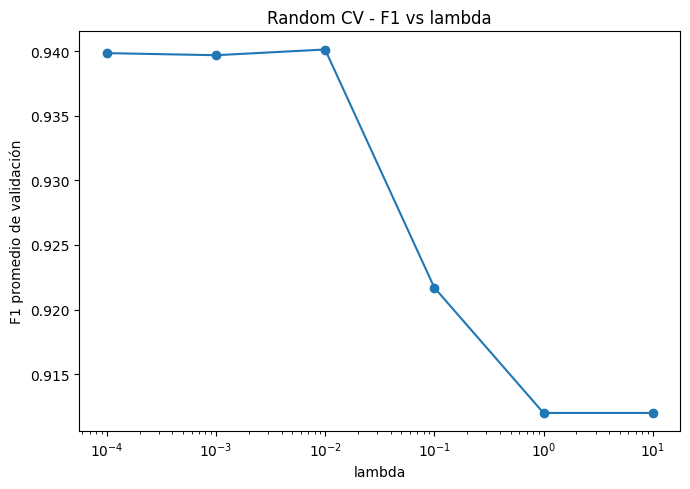

In [23]:
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]

tabla_lambda_random, mejor_lambda_random = buscar_mejor_lambda_random_cv(
    df_bin,
    columnas_numericas,
    columnas_categoricas,
    lambdas,
    n_splits=5,
    random_state=42,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)

tabla_lambda_random

print('Mejor lambda random:', mejor_lambda_random)
graficar_f1_vs_lambda(tabla_lambda_random, 'Random CV - F1 vs lambda')

Para el cross validation se evaluan distintos lambdas y comparo su F1 promedio de validation. Para esto se hicieron folds aleatorios, se entrena el modelo en los de training y se calcula el F1 promedio sobre los folds de validacion. El mejor resultado se obtuvo con lambda = 0.01. Los valores mas chicos de lambda rinden bastante similar, pero al aumentar a partir de 0.1, baja el rendimiento. 
De esto interpreto que una regularizacion demasiado fuerte arruina la capacidad predictiva del modelo este, conviene trabajar con valores bajos de lambda.


Mejor lambda group: 0.001


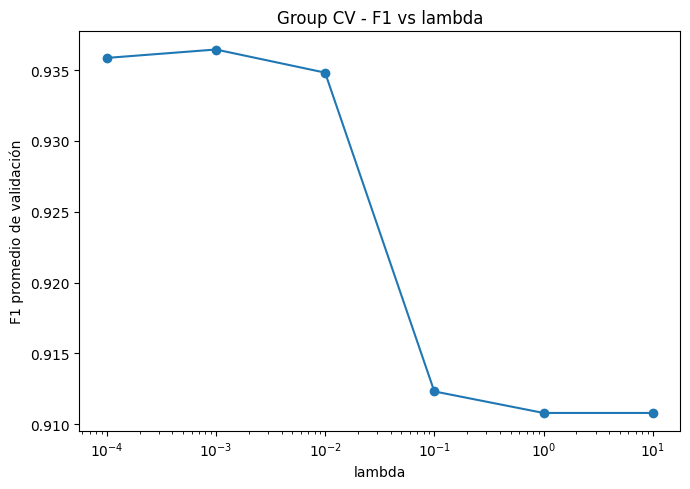

In [24]:
tabla_lambda_group, mejor_lambda_group = buscar_mejor_lambda_group_cv(
    df_bin,
    columnas_numericas,
    columnas_categoricas,
    lambdas,
    n_splits=4,
    random_state=42,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)

tabla_lambda_group

print('Mejor lambda group:', mejor_lambda_group)
graficar_f1_vs_lambda(tabla_lambda_group, 'Group CV - F1 vs lambda')

En el cross validation por grupos, evalue distintos lambdas usando folds hechos por escuela, esto es clave, ya que la validacion se hace sobre escuelas no vistas en training. El mejor resultado fue lambda = 0.001, igual que en el caso de antes, los lambdas bajos rinden bien, asi que incluso en esta regresion que es mas exigente por la division del dataset, no hay que regularizar mucho porque perjudica.

Mejor lambda temporal: 0.01


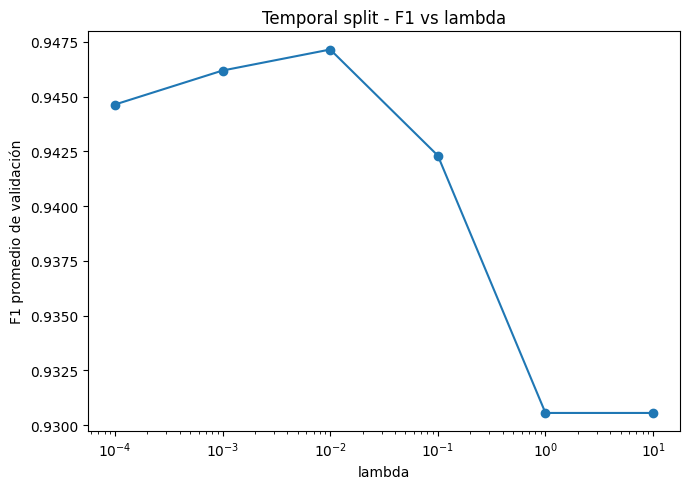

In [25]:
tabla_lambda_temp, mejor_lambda_temp = buscar_mejor_lambda_temporal(
    df_bin,
    columnas_numericas,
    columnas_categoricas,
    lambdas,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)

tabla_lambda_temp

print('Mejor lambda temporal:', mejor_lambda_temp)
graficar_f1_vs_lambda(tabla_lambda_temp, 'Temporal split - F1 vs lambda')

Para el  temporal, se evaluaron los mismos valores de lambda, entrenando sobre los primeros cinco semestres y haciendo validation solo en el ultimo.
Nuevamente el mejor resultado fue con lambda lambda = 0.01

In [26]:
tabla_mejores_lambdas = pd.DataFrame({
    'estrategia': ['Random CV', 'Group CV', 'Temporal split'],
    'mejor_lambda': [mejor_lambda_random, mejor_lambda_group, mejor_lambda_temp]
})

tabla_mejores_lambdas

,estrategia,mejor_lambda
0,Random CV,0.010
1,Group CV,0.001
2,Temporal split,0.010


Los valores obtuvidos son los siguientes:
- Random CV: lambda = 0.01 
- Group CV: lambda = 0.001 
- Temporal split: lambda = 0.01 
No son iguales pero si magnitudes similares, en todos regularizacion baja rinde mejor. Los modelos no necesitan penaliacion fuerte.

## 2.3 Estabilidad de coeficientes

Aca analizo la estabilidad de los coeficientes de la regresion logistica usando cross validation con dos estrategias, Kfold aleatorio y GroupKFold por escuela.
Para que la comparacion sea razonable, uso el mismo valor de regularizacion en ambos casos, despues para cada feature veo la distribucion de sus coeficientes a lo largo de los folds y comparo su desvio estandar. Si el desvio es mas grande, el coeficiente es mas inestable frente a cambios en el dataset de train.

Calculo los coeficientes del model oen cada fold para los dos casos de cross validatrion y despues comparo la estabilidad de cada feature a partir del desvio de sus coeficientes. Grafique boxplots con las features que resultaron mas inestable, para visualizar la variacion de coeficientes y tambien si mantienen o no el signo, magnitud entre folds.

Lambda usado para estabilidad de coeficientes: 0.001


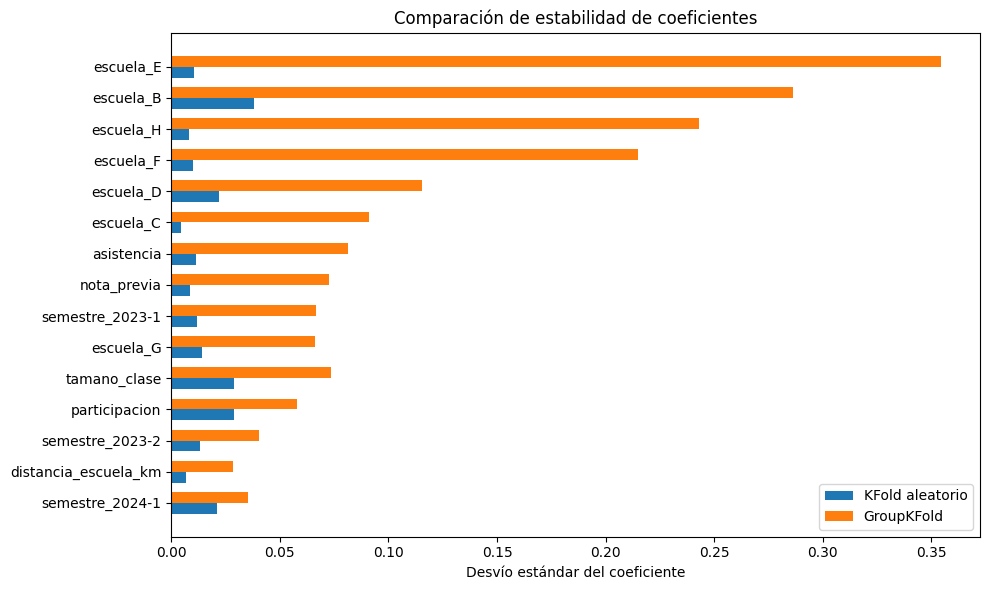

In [27]:
lambda_coef = mejor_lambda_group
print('Lambda usado para estabilidad de coeficientes:', lambda_coef)

coef_random = obtener_coeficientes_random_cv(
    df_bin,
    columnas_numericas,
    columnas_categoricas,
    lambda_reg=lambda_coef,
    n_splits=5,
    random_state=42,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)

coef_group = obtener_coeficientes_group_cv(
    df_bin,
    columnas_numericas,
    columnas_categoricas,
    lambda_reg=lambda_coef,
    n_splits=4,
    random_state=42,
    learning_rate=learning_rate,
    n_iter=n_iter,
    threshold=threshold,
    categorias_fijas=categorias_fijas
)

comparacion_std = comparar_estabilidad_coeficientes(coef_random, coef_group)

comparacion_std.head(15)

graficar_comparacion_estabilidad(
    comparacion_std,
    top_n=15,
    titulo='Comparación de estabilidad de coeficientes'
)

Aca se ve que en general los coeficientes son mas inestables bajo GroupKFold por escuela que bajo KFold aleatorio. Se ve mucho en las variables de las escuelas donde hay muchisima inestabilidad, en otras features tambien como asistencia nota previa, pero menos que las escuelas.

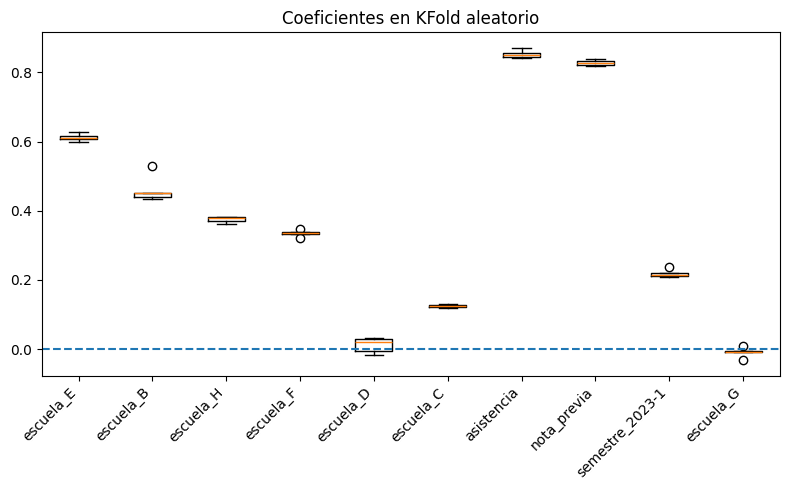

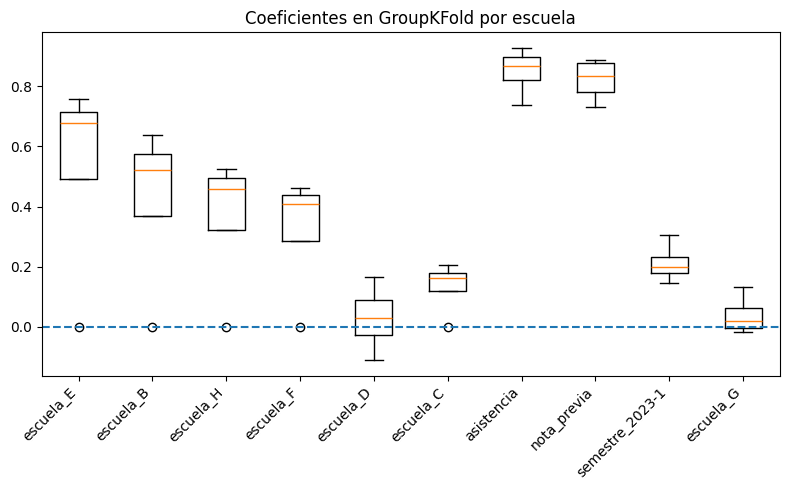

In [28]:
features_mas_inestables = comparacion_std.head(10).index.tolist()

graficar_boxplot_coeficientes(
    coef_random,
    features_mas_inestables,
    'Coeficientes en KFold aleatorio'
)

graficar_boxplot_coeficientes(
    coef_group,
    features_mas_inestables,
    'Coeficientes en GroupKFold por escuela'
)

Los boxplots demuestran lo visto. Con Kfold aleatorio los coeficientes se dispersan menos entre folds que con GroupKFold, donde varios coeficientes varian demasiado, en algunos casos se acercan a 0 incluso. Reitero en que en las variables escuela es donde mas pasa, se esperaba, ya que cuando se deja una escuela completa afuera, en validation, el modelo se entrena con distintas escuelas y los efectos a cada una son inestables.

### Features más inestables bajo GroupKFold
Las features mas inestable bajo GroupKFold son las variables asociadas a la escuela, el poder prouctivo de las mismas depende de que escuelas esten en training. Las que no son de las escuelas, destaco la mayor inestabilidad en asistencia y nota previa/


### Interpretación de la inestabilidad
Si un coeficiente es inestable nos dice que su valor cambia mucho cuando cambia un poco la data de training, asi el efecto que tiene la estimacion aportada por esa feature no es robusta, depende de que escuelas queden en cada fold. Si una variable tiene un coeficiente muy variable emtre folds, su relacion con el target no deberia ser uniforme en todo el dataset, esa feature deberia estar captando patrones especificos por escuela, mas que algo generalizable.

### ¿Cuándo conviene usar cada estrategia?
Si queremos estimaciones realistas de performance en produccion cuando apliquemos el modelo a nuevas escuelas que lleguen, deberiamos usar GroupKFold por escuela, evalua explicitamente la capacidad de generalizacion a grupos no vistos. KFold aleatorio puede ser util si en realidad sabemos que training y test tienen estudiantes de las mismas escuelas, pero esta estrategia estima de forma muy optimista mezclando datos de los mismos grupos en training y validation


La estabilidad de los coeficientes depende mucho de como partimos el dataset, con KFold aleatorio mas estables, y GrouKFold muy inestable por escuela. La escuela introduce estructura de grupo muy fuerte en todo este TP, hace que todo sea mas exigente, pero si buscamos una capacidad de generalizacion realista, esta bueno.

# 3. Clasificación Multiclase y Ensemble Learning
En el punto 3 ya se empieza con la version mutliclase del target rendimiento. Todas las evaluaciones van a ser con GroupKFold por escuela, para no mezclar observaciones de una misma escuela entre train y validation.
Los 3 modelos hechos son Análisis Discriminante Lineal (LDA), Análisis Discriminante Lineal (LDA) y Random Forest con entropía como criterio de división.

Se usa el dataset ya procesado, ademas se recuperan las columnas numericas, categoricas y la variable objetivo, fijandome los nombres de las clases: Insuficiente, Regular, Bueno, Excelente. Tambien construi lista de categorias fijas para las categoricas, para que con los distintos folds de validation, la codificacion sea consistente.

In [29]:
df_multi = cargar_dataset('../data/processed/rendimiento_estudiantes_dev_clean.csv').reset_index(drop=True)

columnas_numericas, columnas_categoricas, target = obtener_columnas()

class_names = ['Insuficiente', 'Regular', 'Bueno', 'Excelente']
categorias_fijas = obtener_categorias_fijas(df_multi, columnas_categoricas)

df_multi[['rendimiento']].head()

,rendimiento
0,Regular
1,Excelente
2,Bueno
3,Excelente
4,Bueno


## 3.1 Modelo 1: LDA

Se entrena un clasificador LDA y se lo evalúa mediante Group-K-Fold por escuela.

In [30]:
def crear_lda():
    return LDAClassifierManual(reg_epsilon=1e-6)

resultado_lda = cross_validar_modelo_group_kfold(
    df_multi,
    crear_lda,
    columnas_numericas,
    columnas_categoricas,
    target_col='rendimiento',
    group_col='escuela',
    n_splits=4,
    random_state=42,
    categorias_fijas=categorias_fijas,
    class_names=class_names
)

display(resultado_lda['tabla_por_clase'])
display(resultado_lda['tabla_resumen'])

,clase,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Insuficiente,0.865560,0.808036,0.221271,0.347409,0.902816,0.645489
1,Regular,0.770660,0.382353,0.034331,0.063005,0.670634,0.319343
2,Bueno,0.565243,0.259403,0.352897,0.299012,0.555129,0.326805
3,Excelente,0.662910,0.511970,0.843380,0.637157,0.829562,0.765233


,accuracy_global,macro_precision,macro_recall,macro_f1,macro_auc_roc,macro_auc_pr
0,0.432187,0.49044,0.36297,0.336646,0.739535,0.514217


### Modelo 1: LDA
El clasificador LDA tiene un rendimiento bastante bajo con validacion GroupKFold por escuela. La accuracy global es de 0.432, macro F1 de 0.337, macro AUC-ROC de 0.740 y macro AUC-PR de 0.514.
El comportamiento por clase es bastante desigual. La clase Excelente es la que mejor capta el modelo, recall alto y F1 de 0.637. Luego las clases Regular e Insuficiente tienen recalls muy bajos, sobre todo Regular, casi no tiene capacidad de deteccion, recall de 0.034. 
Vemos que a este clasificador le cuesta separar bien las 4 clases y favorece la clase mas facil de identificar, las categorias intermedias las confunde mucho.

## 3.1 Modelo 2: Regresión logística multiclase

Se entrena una regresión logística multiclase con regularización L2 y se la evalúa con Group-K-Fold por escuela.

In [31]:
def crear_logistica_multiclase():
    return LogisticRegressionMulticlass(
        learning_rate=0.05,
        n_iter=5000,
        lambda_reg=0.1,
        tol=1e-7,
        verbose=False
    )

resultado_logistica_multi = cross_validar_modelo_group_kfold(
    df_multi,
    crear_logistica_multiclase,
    columnas_numericas,
    columnas_categoricas,
    target_col='rendimiento',
    group_col='escuela',
    n_splits=4,
    random_state=42,
    categorias_fijas=categorias_fijas,
    class_names=class_names
)

display(resultado_logistica_multi['tabla_por_clase'])
display(resultado_logistica_multi['tabla_resumen'])

,clase,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Insuficiente,0.838078,0.498024,0.154034,0.235294,0.908651,0.603970
1,Regular,0.718268,0.404114,0.536092,0.460840,0.774287,0.378437
2,Bueno,0.718268,0.444700,0.290444,0.351388,0.693824,0.376792
3,Excelente,0.835706,0.694239,0.950423,0.802378,0.951779,0.914179


,accuracy_global,macro_precision,macro_recall,macro_f1,macro_auc_roc,macro_auc_pr
0,0.55516,0.510269,0.482748,0.462475,0.832135,0.568345


### Modelo 2: Regresión logística multiclase

La regresión logística multiclase mejora de forma clara el desempeño obtenido con LDA. Bajo Group-K-Fold por escuela, alcanza una **accuracy global de 0.555**, **macro F1 de 0.462**, **macro AUC-ROC de 0.832** y **macro AUC-PR de 0.568**.

La mejora más notoria aparece en la clase **Regular**, cuyo **recall sube a 0.536** y cuyo **F1 alcanza 0.461**, muy por encima de lo observado con LDA. La clase **Excelente** sigue siendo la mejor modelada, con **recall de 0.950** y **F1 de 0.802**.

Sin embargo, el modelo todavía presenta dificultades para recuperar correctamente las clases **Insuficiente** y **Bueno**, especialmente la primera. Esto muestra que, aunque la logística multiclase representa un avance importante respecto de LDA, el problema sigue siendo desafiante y el desempeño no es homogéneo entre clases.

## 3.1 Modelo 3: Random Forest

Se prueba un conjunto pequeño de configuraciones para Random Forest y se selecciona la mejor según el macro F1 promedio obtenido con Group-K-Fold por escuela.

In [32]:
configs_rf = [
    {
        'n_estimators': 10,
        'max_depth': 5,
        'min_samples_split': 8,
        'min_samples_leaf': 3,
        'max_features': 'sqrt',
        'bootstrap': True,
        'random_state': 42
    },
    {
        'n_estimators': 15,
        'max_depth': 6,
        'min_samples_split': 6,
        'min_samples_leaf': 2,
        'max_features': 'sqrt',
        'bootstrap': True,
        'random_state': 42
    },
    {
        'n_estimators': 20,
        'max_depth': 8,
        'min_samples_split': 6,
        'min_samples_leaf': 2,
        'max_features': 'sqrt',
        'bootstrap': True,
        'random_state': 42
    },
    {
        'n_estimators': 20,
        'max_depth': None,
        'min_samples_split': 4,
        'min_samples_leaf': 1,
        'max_features': 'sqrt',
        'bootstrap': True,
        'random_state': 42
    }
]

In [33]:
tabla_rf_configs, mejor_config_rf = buscar_mejor_config_random_forest_group_kfold(
    df_multi,
    configs_rf,
    RandomForestClassifierManual,
    columnas_numericas,
    columnas_categoricas,
    target_col='rendimiento',
    group_col='escuela',
    n_splits=4,
    random_state=42,
    categorias_fijas=categorias_fijas,
    class_names=class_names
)

display(tabla_rf_configs)
mejor_config_rf

,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,bootstrap,random_state,accuracy_global,macro_precision,macro_recall,macro_f1,macro_auc_roc,macro_auc_pr
0,20,NaN,4,1,sqrt,True,42,0.573151,0.557725,0.514526,0.517552,0.824000,0.571695
1,20,8.0,6,2,sqrt,True,42,0.554172,0.534563,0.484579,0.478046,0.819136,0.549697
2,15,6.0,6,2,sqrt,True,42,0.522539,0.480569,0.444946,0.429842,0.796043,0.510708
3,10,5.0,8,3,sqrt,True,42,0.498023,0.447388,0.416774,0.397466,0.774019,0.481296


{'n_estimators': 20,
 'max_depth': nan,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'bootstrap': True,
 'random_state': 42,
 'accuracy_global': 0.5731514432582048,
 'macro_precision': 0.5577253904643643,
 'macro_recall': 0.514526206483142,
 'macro_f1': 0.5175521749670606,
 'macro_auc_roc': 0.8239999881026939,
 'macro_auc_pr': 0.5716949218702381}

In [34]:
campos_metricas = [
    'accuracy_global',
    'macro_precision',
    'macro_recall',
    'macro_f1',
    'macro_auc_roc',
    'macro_auc_pr'
]

mejor_config_rf_limpia = {
    k: v for k, v in mejor_config_rf.items() if k not in campos_metricas
}

if pd.isna(mejor_config_rf_limpia['max_depth']):
    mejor_config_rf_limpia['max_depth'] = None

mejor_config_rf_limpia

{'n_estimators': 20,
 'max_depth': None,
 'min_samples_split': 4,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'bootstrap': True,
 'random_state': 42}

### Modelo 3: Random Forest
Para el Random Forest probe distintas configuraciones de hiperparametros, variando la cantidad de arboles, la complejidad de cada uno y demas, la seleccion fue con
Group-K-Fold por escuela. La mejor configuracion fue la siguiente:
- 20 árboles
- profundidad máxima no restringida
- min_samples_split = 4
- min_samples_leaf = 1
- max_features = sqrt

Se puede decir que en general las configuraciones mas flexibles rinden mejor que con arboles mas restringidos, esto nos dice que el problema de clasificacion que tenemos tiene relaciones complejas entre features y target.

In [35]:
def crear_random_forest_mejor():
    return RandomForestClassifierManual(**mejor_config_rf_limpia)

resultado_rf = cross_validar_modelo_group_kfold(
    df_multi,
    crear_random_forest_mejor,
    columnas_numericas,
    columnas_categoricas,
    target_col='rendimiento',
    group_col='escuela',
    n_splits=4,
    random_state=42,
    categorias_fijas=categorias_fijas,
    class_names=class_names
)

display(resultado_rf['tabla_por_clase'])
display(resultado_rf['tabla_resumen'])

,clase,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Insuficiente,0.858047,0.637363,0.283619,0.392555,0.886981,0.578361
1,Regular,0.736853,0.418273,0.439261,0.428510,0.763023,0.401639
2,Bueno,0.698893,0.430615,0.452972,0.441511,0.713826,0.424672
3,Excelente,0.852511,0.744650,0.882254,0.807633,0.932170,0.882107


,accuracy_global,macro_precision,macro_recall,macro_f1,macro_auc_roc,macro_auc_pr
0,0.573151,0.557725,0.514526,0.517552,0.824,0.571695


### Evaluación del Random Forest
Con la mejor configuracion, el Random Forest tiene accuracy global de 0.573, macro F1 de 0.518, macro AUC-ROC de 0.824 y macro AUC-PR de 0.572. El desempeno por clase sigue variando, la clase Excelente es la que mejor se modela, recall de 0.882 y F1 de 0.808, y la clase insuficiente sigue siendo la mas complicada. Las clases Regular y Bueno tienen desempenos intermedios, con valores de F1 moderados. El random forest captura un poco mejor el problema que modelos simples pero sigue teniendo muchas diferencias de rendimiento entre clases.

## 3.2 Comparación entre modelos

Se comparan LDA, regresión logística multiclase y Random Forest utilizando métricas globales y métricas one-vs-all por clase.

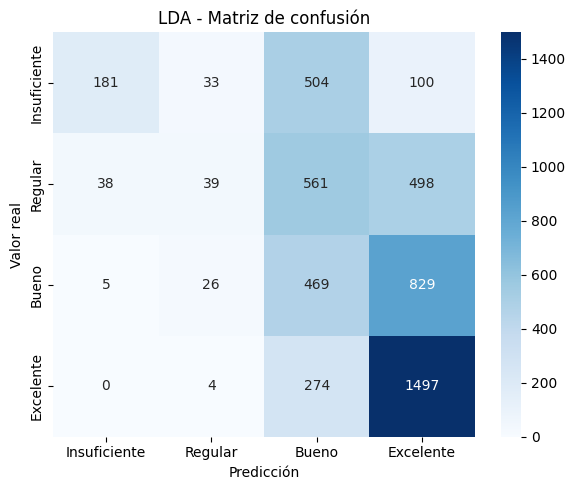

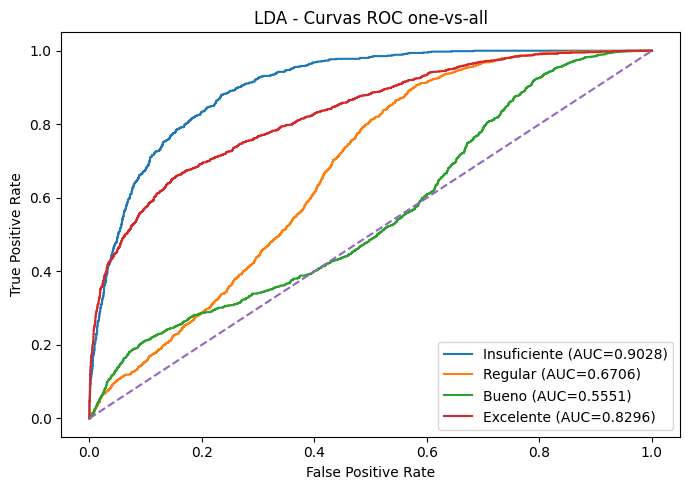

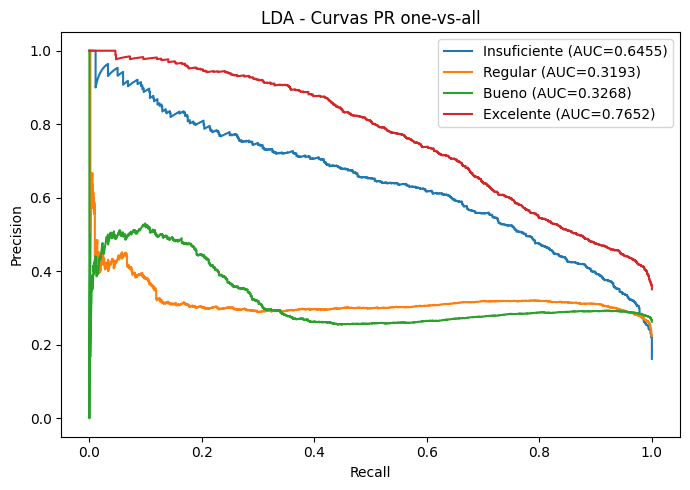

In [36]:
graficar_matriz_confusion_multiclase(
    resultado_lda['matriz_confusion'],
    class_names,
    'LDA - Matriz de confusión'
)

graficar_roc_multiclase_ovr(
    resultado_lda['curvas_roc'],
    'LDA - Curvas ROC one-vs-all'
)

graficar_pr_multiclase_ovr(
    resultado_lda['curvas_pr'],
    'LDA - Curvas PR one-vs-all'
)

### Matriz de confusión de LDA
Se ve lo dificil que es separar correctamente las clases, La clase Excelente es la que mejor se reconoce, Regular es muy problematica, con pocos casos correctos clasificados. Muchas observaciones de Insuficiente y Regular son clasificadas como Bueno o Excelente, y tambien muchos Bueno se clasifican como Excelente. El modelo
desplaza las las predicciones a rendimientos mas altos.

### Curvas ROC one-vs-all de LDA
Las Curvas ROC tambien que el modelo se comporta distint osegun la clase. Insuficiente tiene AUC ROC alto, Excelente tambien tiene un valor relativamente bueno, Regular tiene desempeno intermedio y Bueno es la peor. LDA ordena relativamente bien algunas clases en terminos de probabilidad, pero eso no lo traduce a buenas decisiones finales sobre las clases, sobre todo las intermedias.

### Curvas Precision-Recall one-vs-all de LDA
Las curvas Precision-Recall nos dicen mas de lo mismo. La clase Excelente es la mejor, Regular y Bueno tienen curvas mas debiles y AUC PR bajos. Estas curvas son informativas cuando hay desbalance entre clases, entonces nos sigue diciendo que es muy dificil recuperar bien las clases menos favorecidas por la estructura del dataset.

LDA no puede modelar de forma equilibrada las cuatro clases, su mejor desempeno es con la clase Excelente , le cuesta mucho distinguir regular, y en menor medida Bueno e Insuficiente, el modelo no puede captar toda la complejidad del modelo con validacion por escuela.

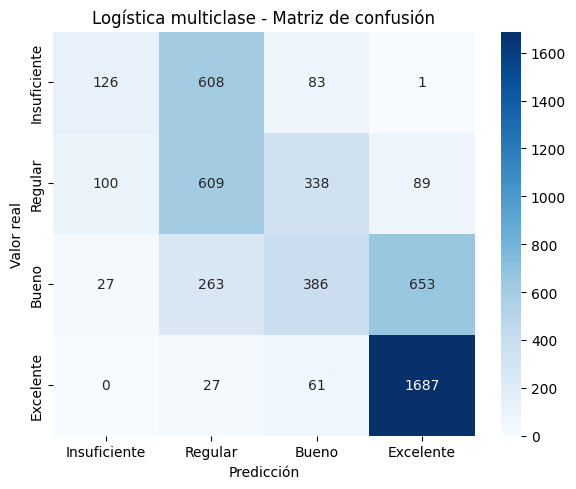

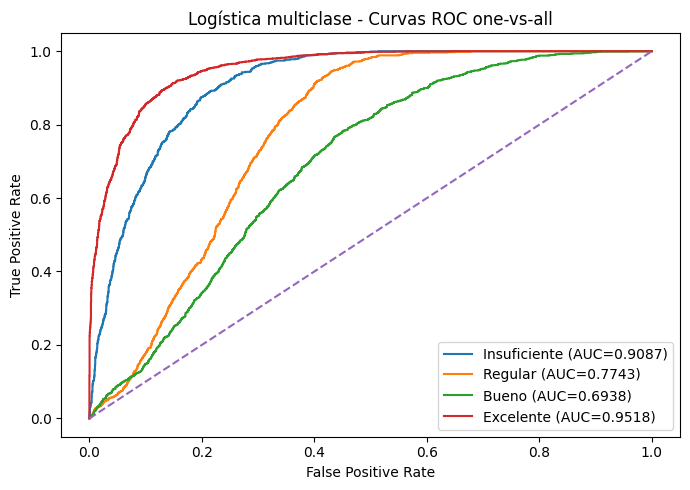

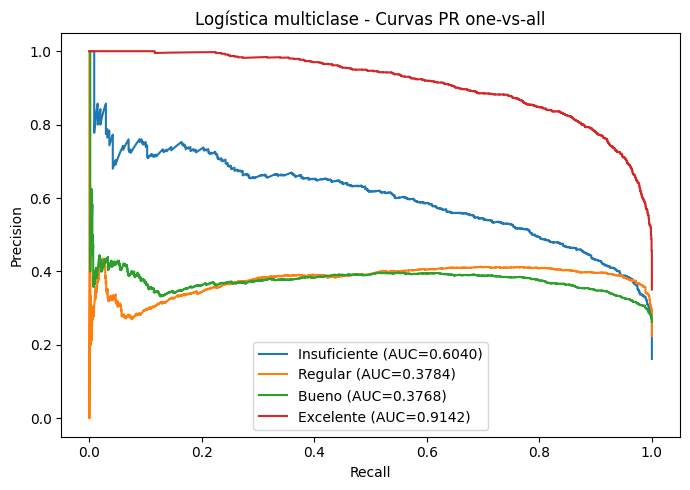

In [37]:
graficar_matriz_confusion_multiclase(
    resultado_logistica_multi['matriz_confusion'],
    class_names,
    'Logística multiclase - Matriz de confusión'
)

graficar_roc_multiclase_ovr(
    resultado_logistica_multi['curvas_roc'],
    'Logística multiclase - Curvas ROC one-vs-all'
)

graficar_pr_multiclase_ovr(
    resultado_logistica_multi['curvas_pr'],
    'Logística multiclase - Curvas PR one-vs-all'
)

### Matriz de confusión de la regresión logística multiclase
De nuevo, Excelente es la clase que mejor se reconoce, en las demas vemos que Insuficiente se confunde mucho con Regular, Regular se confunde con Bueno, y Bueno con Excelente. Vemos el patron de error, el modelo capta de alguna forma la estructura ordenada del target, pero le cuesta separar con claridad las clases.

### Curvas ROC one-vs-all de la regresión logística multiclase
Las curvas ROC muestran distintos desempenos, de nuevo Excelente tiene la mejor separacion, Insuficente tambien tiene un buen valor de AUC ROC, pero Regular y sobre todo Bueno, estan mas limitadas para separar. Puedo decir que el modelo distingue bien clases extremas pero le cuestan mas las categorias intermedias.

### Curvas Precision-Recall one-vs-all de la regresión logística multiclase
Las Precision Recall nos dicen mas de lo mismo, Excelente la mejor con alta precision a medida que crece el Recall, Insuficiente tiene un rendimiento intermedio, Regular y Bueno tienen curvas mas debiles. La regresion logistica multiclase sirve para identtificar la clase mas DISTINGUIBLE del problema, pero le cuesta modelar todas las categorias.


El comportamiento de este modelo es mas razonable que el de uno mas restrictivo, porque sus errores son entre clases cercanas, sin embargo el desempeno sigue siendo desigual por clase.

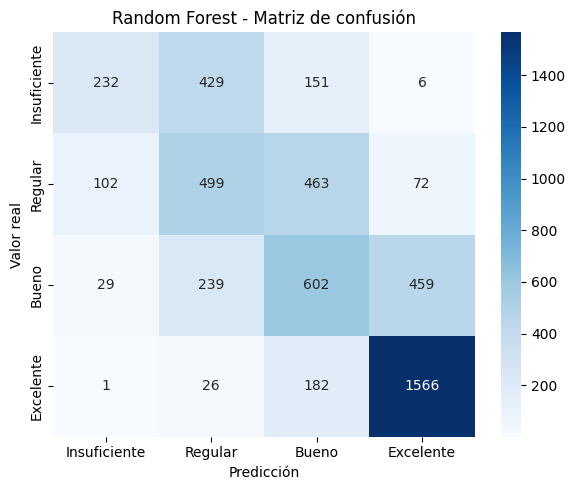

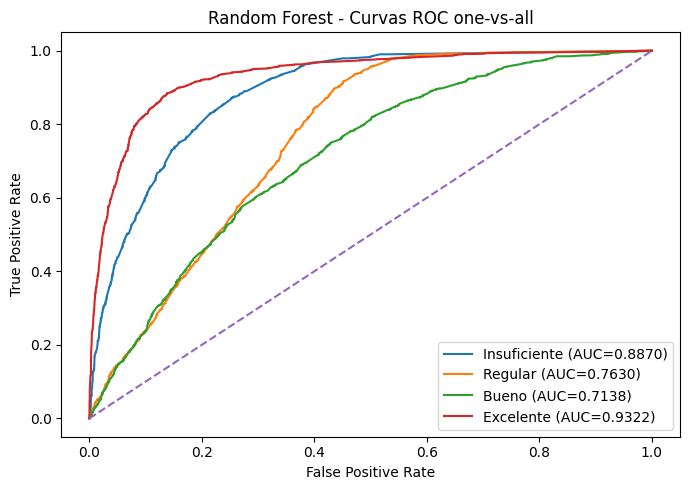

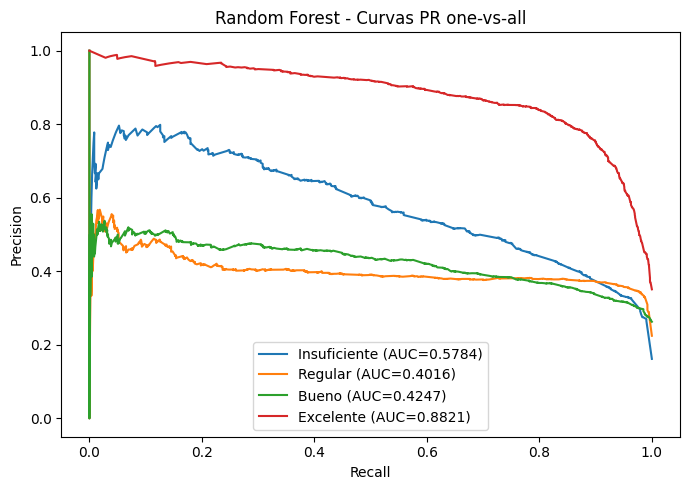

In [38]:
graficar_matriz_confusion_multiclase(
    resultado_rf['matriz_confusion'],
    class_names,
    'Random Forest - Matriz de confusión'
)

graficar_roc_multiclase_ovr(
    resultado_rf['curvas_roc'],
    'Random Forest - Curvas ROC one-vs-all'
)

graficar_pr_multiclase_ovr(
    resultado_rf['curvas_pr'],
    'Random Forest - Curvas PR one-vs-all'
)

### Matriz de confusión de Random Forest
Se identifica bastante bien la clase Excelente, Insuficiente es lam as dificil y la muchas de sus observaciones se clasifican como Regular. Los errores tambien se concentran en clases cercanas, Regular con Bueno, Bueno con Excelente.

### Curvas ROC one-vs-all de Random Forest
Sigue habiendo desempeno desigual entre clases, Excelente la mejor seguida por Insuficiente, Regular y Bueno con valores mas bajos, menor capacidad de separacion frente a las primeras dos. De nuevo se distinguen mejor las clases extremas que las intermedias.

### Curvas Precision-Recall one-vs-all de Random Forest
Se confirma que la clase Excelente es la mejor modelada, precision alta a medida que aumenta el recall, Insuficiente rinde de forma intermedia, Regular y Bueno tienen las peores curvas y AUC PR menores. Se logra un desempeno razonable en alguna categorias, pero de nuevo no es igual el desempeno en todas las clases.


Random Forest si captura mejor la estructura del problema que un modelo lineal, tiene un patron de errores coherente, parecido a lo anterior, seguimos viendo lo mismo que antes.

In [39]:
resultados_modelos = {
    'LDA': resultado_lda,
    'Logística multiclase': resultado_logistica_multi,
    'Random Forest': resultado_rf
}

tabla_comparativa_modelos = armar_tabla_comparativa_modelos(resultados_modelos)
display(tabla_comparativa_modelos)

,modelo,accuracy_global,macro_precision,macro_recall,macro_f1,macro_auc_roc,macro_auc_pr
0,LDA,0.432187,0.490440,0.362970,0.336646,0.739535,0.514217
1,Logística multiclase,0.555160,0.510269,0.482748,0.462475,0.832135,0.568345
2,Random Forest,0.573151,0.557725,0.514526,0.517552,0.824000,0.571695


## Comparación global de modelos
LDA es el modelo con menor desempeno global con los valores más bajos de accuracy, macro recall y macro F1, es muy limitada la capacidad de separar las cuatro clases. La regresión logística multiclase es bastante mejor que LDA, pero el mejor resultado se obtiene con Random Forest, tiene los valores más altos de accuracy global, macro precision, macro recall, macro F1 y macro AUC-PR. Si importa decir que tanto la logistica multiclase como el Random Forest hacen un buen ranking probabilistico por el macro auc Roc, por mas que luego Random Forest tome mejores decisiones finales.

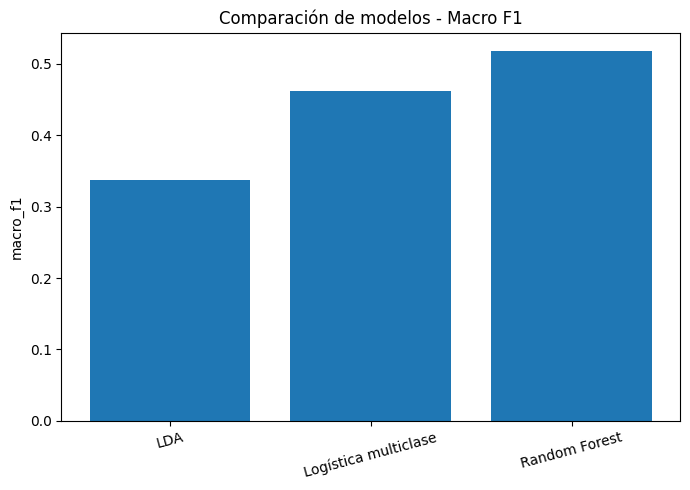

In [40]:
graficar_comparacion_modelos(
    tabla_comparativa_modelos,
    metrica='macro_f1',
    titulo='Comparación de modelos - Macro F1'
)

### Comparación según macro F1
Random forest es el mas equlibrado entre las distintas clases, lo sigue la regresion logistica multiclase y por ultimo LDA. El macro F1 promedia el desemeno por clase sin favorecer a las clases mas frecuentes, es util esta metrica para el problema que tenemos, el resultado nos dice que Random Forest tiene la mejor combinacion global entre precision y recall sobre el conjunto de clases.

,clase,f1,modelo
0,Insuficiente,0.347409,LDA
1,Regular,0.063005,LDA
2,Bueno,0.299012,LDA
3,Excelente,0.637157,LDA
4,Insuficiente,0.235294,Logística multiclase
5,Regular,0.460840,Logística multiclase
6,Bueno,0.351388,Logística multiclase
7,Excelente,0.802378,Logística multiclase
8,Insuficiente,0.392555,Random Forest
9,Regular,0.428510,Random Forest


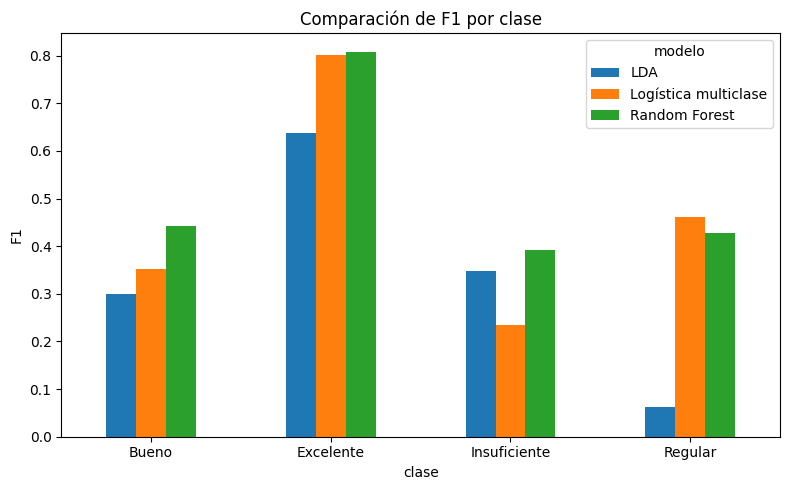

In [41]:
tabla_f1_por_clase = armar_tabla_f1_por_clase_modelos(resultados_modelos)
display(tabla_f1_por_clase)

graficar_f1_por_clase_modelos(
    tabla_f1_por_clase,
    titulo='Comparación de F1 por clase'
)

### Comparación de F1 por clase
Ya sabiamos esto pero se visualiza, Random Forest tiene el mejor F1 en Insuficiente, Bueno y Excelente, mientras que la regresión logística multiclase logra el mejor desempeño en la clase Regular. Esta bueno notar esto, si bien Random Forest es el mejor modelo globalmente, la regresion logistica compite y le va mejor en una de las clases intermedias.

## Importancia de features en Random Forest


In [42]:
display(resultado_rf['feature_importances'].head(20))

tamano_clase             0.166866
nivel_socioeconomico     0.113104
asistencia               0.109919
nota_previa              0.091971
horas_estudio            0.079230
participacion            0.079175
horas_sueno              0.057287
distancia_escuela_km     0.055850
horas_extracurricular    0.052730
escuela_G                0.030828
escuela_D                0.028357
escuela_C                0.023420
acceso_internet          0.019036
escuela_E                0.016553
escuela_B                0.015380
semestre_2024-2          0.009601
escuela_H                0.009234
semestre_2022-2          0.009131
semestre_2023-1          0.008468
semestre_2023-2          0.008419
dtype: float64


Las mas importantes son tamano_clase, nivel_socioeconomico, asistencia, nota_previa, horas_estudio y participacion. En general coincide con lo esperado, muchas son informativas para explicar el rendimiento, asi que que sean importantes es razonable. Nivel socioeconomico aparece en las primeras posiciones asi que nos dice que el contexto del estudiante tambien influye mucho. Lo mas llamativo es que tamano clase es la feature mas importante, puede ser que la misma este asociada al rendimiento lo cual tiene sentido, si la clase es mas chica capaz se entiende mas todo o algo por el estilo, o tambien puede ser que la mismas variable este captando diferencias entre contextos escolares (habiamos visto que el tamano variaba segun la escuela). Varias dummies de escuela aparecen como importantes, tambien hay algo contextual por escuela que determina el rendimiento, las variables de semestre en cambio no tienen tanto efecto.

### Observación sobre la interpretación
Estas importancias no debemos interpretarlas en terminos causales. En Random Forest la importancia de una feature vrefleja cuanto contribuye a reducir la impureza en los arboles, pero no necesariamente indica una relacion causal con el target. Ademas las variables categoricas fueron codificadas con one hot encoding, su importancia se distribuye entre columnas, por ejemplo la importancia total de escuela seguor sea mayor que la de cada dummy por separado.

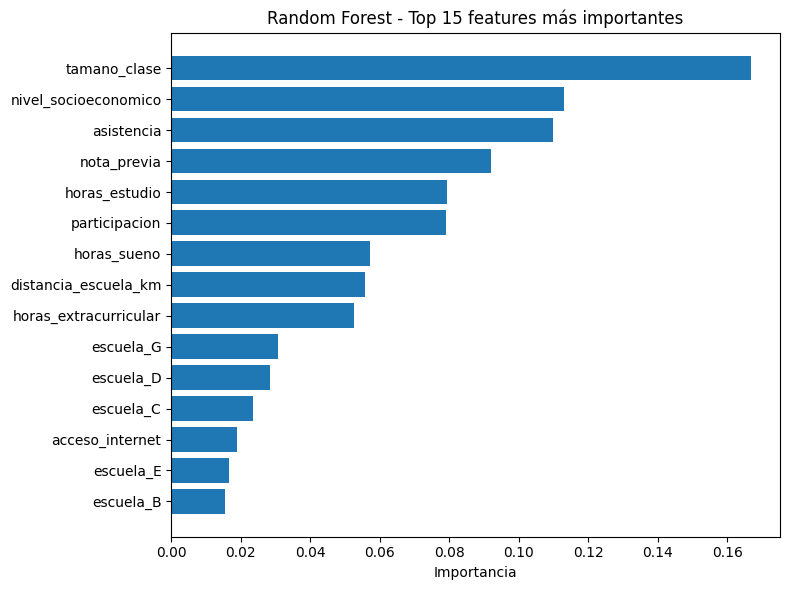

In [43]:
graficar_importancia_features(
    resultado_rf['feature_importances'],
    top_n=15,
    titulo='Random Forest - Top 15 features más importantes'
)

## Conclusión de la sección 3
Evalue LDA, regresión logística multiclase con regularización y Random Forest utilizando Group-KFold por escuela, esto permite medir la capacidad de generalizacion a grupos no vistos, es mas exigente que una particion aleatoria. Los tres modelos mostraron un comportamiento desigual entre clases, la clase Excelente fue la más fácil de identificar, Regular y Bueno las mas complicadas, esto se ve en las matrices de confusion en las curbas ROC y Precision Recall. 
LDA fue la que peor le fue, la regresión logística multiclase es bastante mejor, y por encima de esta el Random Forest. 
Por ultimo analice que tan importante eran cada feature del mejor Random Forest, y explique un poco de eso. Hasta aca diria que el Random Forest es el modelo mas adecuado para este problema, que es bastante complejo, pero no le fue tan mal bajo validacion por escuela.  

# 4. Manejo de Desbalanceo de Clases
Aclaracion: en esta seccion hay que evaluar como se comporta el modelo sobre la clase minoritaria que es Desaprobados (Insuficiente). Por eso cuando se calculas las metricas inverti la codificacion binaria de modo que la clase minoritaria sea la positiva, asi precision, recall, F1, RCO y PR quedan orientadas a medir la capacidad de detectar estudiantes desaprobados. En la seccion 2 del trabajo practico esto era distinto, por eso se hicieron las respectivas aclaraciones.

Vuelvo a usar la version binaria del target, se usa Group-K-Fold por escuela para evaluar el desempeno del modelo. Se comparan 5 tecnicas de desbalanceo sobre regresión logística binaria con regularización L2, en cada fold el rebalanceo se hace solo sobre el conjunto de train y el de validation no se cambia, las 5 tecnicas son:
- sin rebalanceo,
- undersampling,
- oversampling por duplicación,
- oversampling mediante SMOTE,
- cost re-weighting.

In [44]:
df_bin = df_clean.copy()

columnas_numericas, columnas_categoricas, target = obtener_columnas()
categorias_fijas = obtener_categorias_fijas(df_bin, columnas_categoricas)

lambda_reg_4 = 0.1
learning_rate_4 = 0.05
n_iter_4 = 5000
threshold_4 = 0.5

En la comparación de técnicas de rebalanceo se mantuvo fijo el valor de regularización (lambda = 0.1) para aislar el efecto del rebalanceo bajo una misma configuración del modelo.

## 4.1 Evaluación de técnicas de rebalanceo
Comparamos las 5 estrategias y es importante recordar que las metricas se calculan tomando a la clase minoritaria, desaprobado (insuficiente) como caso postivo para evaluar, ya que es lo que mas nos interesa.

In [45]:
tecnicas_rebalanceo = [
    'sin_rebalanceo',
    'undersampling',
    'oversampling_duplicate',
    'smote',
    'cost_reweighting'
]

resultados_rebalanceo = {}

for tecnica in tecnicas_rebalanceo:
    print('Corriendo:', tecnica)

    resultado = cross_validar_rebalanceo_group_kfold(
        df_bin,
        tecnica=tecnica,
        columnas_numericas=columnas_numericas,
        columnas_categoricas=columnas_categoricas,
        target_col='rendimiento_binario',
        group_col='escuela',
        n_splits=4,
        random_state=42,
        categorias_fijas=categorias_fijas,
        lambda_reg=lambda_reg_4,
        learning_rate=learning_rate_4,
        n_iter=n_iter_4,
        threshold=threshold_4,
        evaluar_minoritaria=True
)
    resultados_rebalanceo[tecnica] = resultado

tabla_rebalanceo = tabla_resultados_rebalanceo(resultados_rebalanceo)
display(tabla_rebalanceo)

Corriendo: sin_rebalanceo
Corriendo: undersampling
Corriendo: oversampling_duplicate
Corriendo: smote
Corriendo: cost_reweighting


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC-PR
0,Sin rebalanceo,0.841439,1.000000,0.019560,0.038369,0.918789,0.675641
1,Undersampling,0.818703,0.469004,0.915648,0.620290,0.933638,0.729186
2,Oversampling duplicate,0.817517,0.467208,0.914425,0.618437,0.934657,0.734003
3,Oversampling SMOTE,0.820680,0.471710,0.907090,0.620661,0.933841,0.731466
4,Cost re-weighting,0.817121,0.466500,0.910758,0.616977,0.934251,0.732875


### Resultados

Se ve que no rebalancear produce la mayor accuracy y una precision perfecta, el tema es que el recall es bajisimo sobre la clase minoritaria, casi nunca logra identificar a los insuficientes, entonces si, la accuracy es alta, pero no es util el modelo si queres identificar los casos mas problematicos como estos.
Las tecnicas de rebalanceo mejoran mucho la deteccion de la clase minoritaria, undersampling, oversapling duplicate, Smote y cost re weighting llegan a recalls de 0.90 aproximadamente todos, mejoran muchisimo frente al anterior caso.
Las diferencias entre las tecnicas son pocas, Undersampling tiene el mejor recall, Smote el mejor F1, oversampling suplicate los mejores AUC ROC y AUC PR pero todo ocn pocas diferencias.
Si nos interesa detectar bien a la clase minoritaria, cualquier estrategia de rebalanceo es muy util y ampliamente superior a no rebalancear, por mas que baje un poco la accuracy.

### Matrices de confusión
Las matrices nos van a permitir visualizar como cambia el comportamiento del modelo segun la tecnica de rebalanceo. Recorar que la clase positiva es la minoritaria, Insuficiente. El foco se pone en ver cuantos insuficientes logra detectar el modelo y cuantos falsos positivos genera.

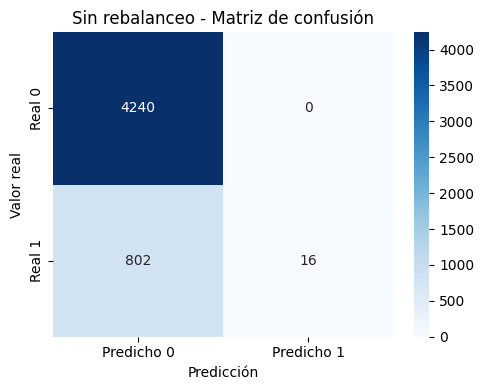

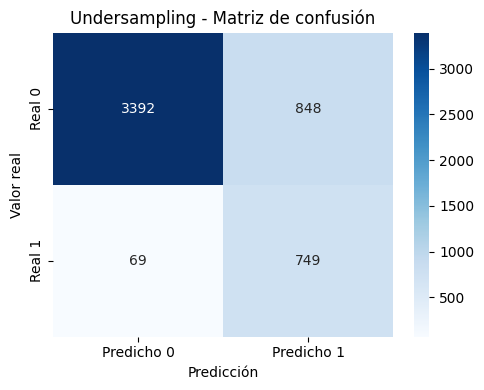

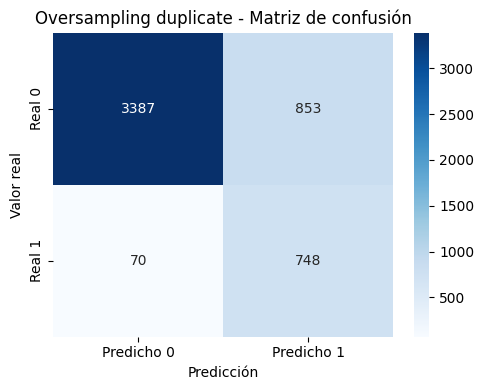

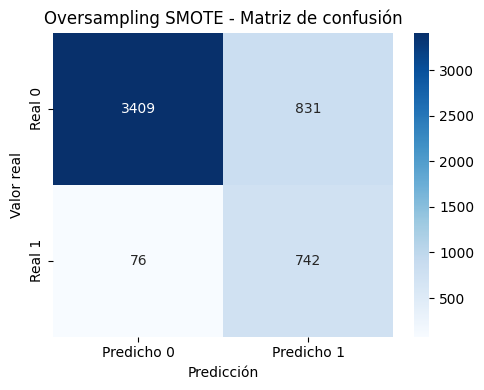

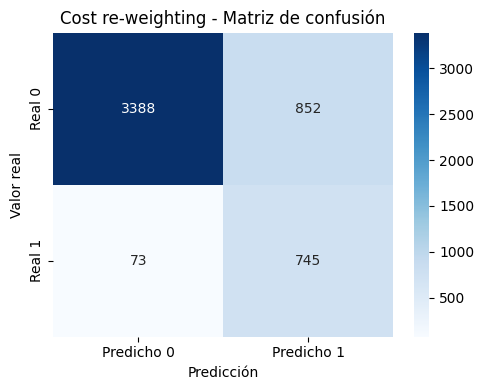

In [46]:
nombres_rebalanceo = {
    'sin_rebalanceo': 'Sin rebalanceo',
    'undersampling': 'Undersampling',
    'oversampling_duplicate': 'Oversampling duplicate',
    'smote': 'Oversampling SMOTE',
    'cost_reweighting': 'Cost re-weighting'
}

for tecnica in tecnicas_rebalanceo:
    graficar_matriz_confusion(
        resultados_rebalanceo[tecnica]['matriz_confusion'],
        f'{nombres_rebalanceo[tecnica]} - Matriz de confusión'
    )

Lo que vimos en las metricas se visualiza aca en las matrices. Sin rebalancear se clasifica casi todo como clase negativa, evita falsos positivos pero no detecta casos insuficientes, solo una fraccion minima.
En cambio todas las tecnicas de rebalanceo producen un fuerte cambio en el patron de prediccion, el modelo reconoce gran cantidad de casos insuficientes, reduciendo mucho los falsos negativos (insuficientes clasificados como no Insuficientes). Sin embargo si aparecen mas falsos positivos sobre la clase mayoritaria, es decir se empiezan a clasificar No insuficientes como Insuficientes, algo esperable si queriamos mejorar las predicciones sobre la clase minoritaria. Se ve que entre las tecnicas hay pocas diferencias, Undersampling tiene la mayor cantidad de verdaderos positivos y menor cantidad de falsos negativos. Rebalancear cambia mucho las prioridades del modelo, deja de favorecer exclusivamente a la clase mayoritaria y pasa a detectar mejor a los insuficientes.

### Curvas ROC y Precision-Recall
Comparo curvas Roc y Precision-Recall de cada tecnica, para evaluar el comportamient odel modelo para distintos umbrales de decision, lo que mas nos interesa es detectar bien la clase minoritaria, entonces Precision-Recall deberia ser la mas informativa.

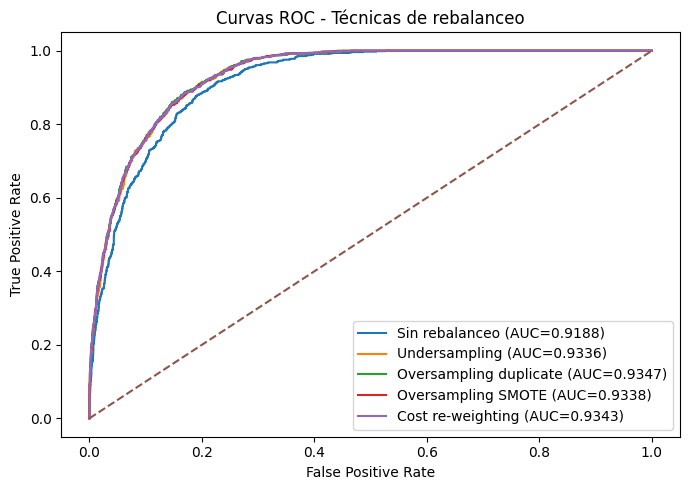

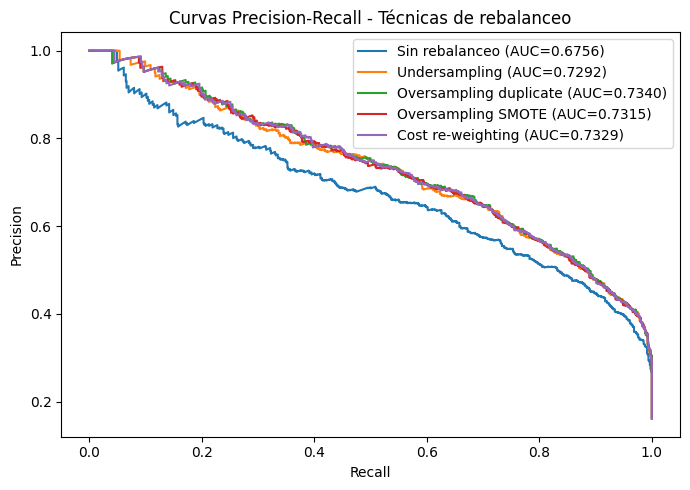

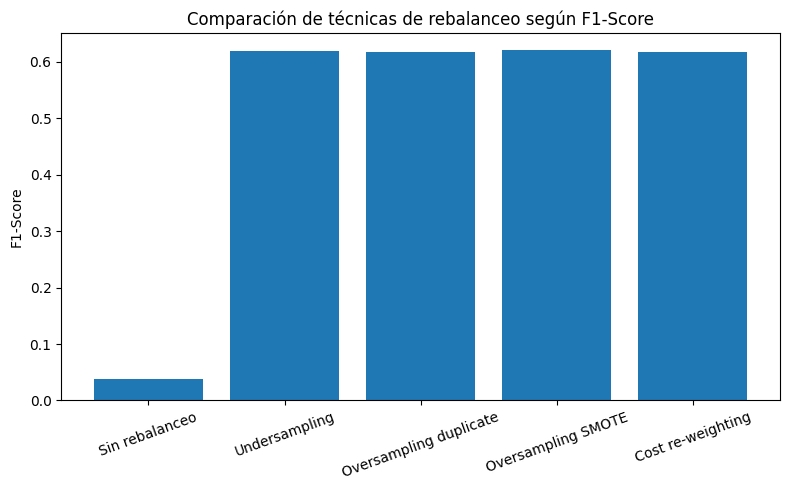

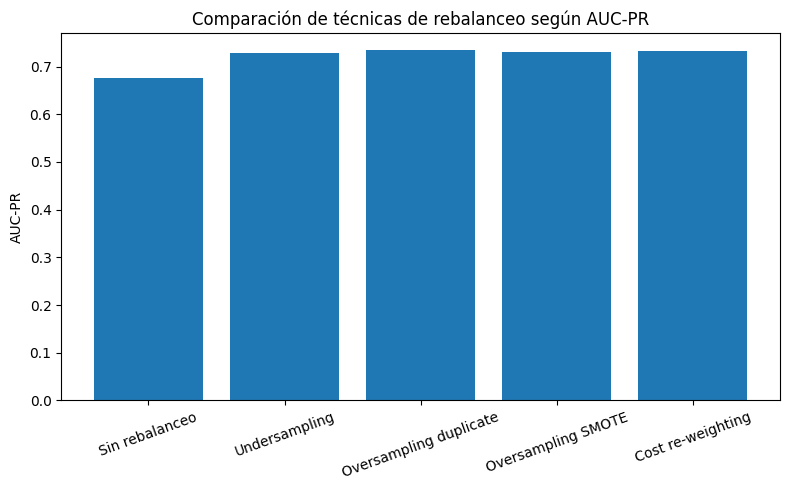

In [47]:
graficar_curvas_roc_rebalanceo(
    resultados_rebalanceo,
    titulo='Curvas ROC - Técnicas de rebalanceo'
)

graficar_curvas_pr_rebalanceo(
    resultados_rebalanceo,
    titulo='Curvas Precision-Recall - Técnicas de rebalanceo'
)

graficar_comparacion_rebalanceo(
    tabla_rebalanceo,
    metrica='F1-Score',
    titulo='Comparación de técnicas de rebalanceo según F1-Score'
)

graficar_comparacion_rebalanceo(
    tabla_rebalanceo,
    metrica='AUC-PR',
    titulo='Comparación de técnicas de rebalanceo según AUC-PR'
)

### Comentario sobre la curva ROC
Se ve que todas las tecnicas superan al caso sin rebalancear, al variar el umbral de clasificacion los modelos rebalanceados logran separar mejor la clase minoritaria y mayoritaria. De nuevo las diferencias entre las distintas tecnicas son pocas.

### Comentario sobre la curva Precision-Recall
Se ve con mas claridad el efecto del rebalanceo sobre la clase minoritaria, el caso sin rebalanceo queda muy por debajo del resto en todo el rango del recall, entonces es mas adecuado rebalancear de la forma que sesa si queremos detectar insuficientes.

### Comentario sobre F1-Score
El grafico tambien confirma que la mejora de rendimiento es drastica usando rebalanceo que sin usarlo. La mejor performance en F1 la tiene SMOTE, con pocas diferencias.

### Comentario sobre AUC-PR
El grafico de AUC PR sigue teniendo sentido, no hay tanta diferencia entre el caso sin rebalanceo que con las 4 tecnicas ya que si bien las tecnicas hacen que se identifique mejor a insuficiente, el AUC PR al evaluar el ranking de probabilidades a lo largo de todos los umbrales, no va a ser bajo en el caso sin rebalanceo, ordena de forma razonable los ejemplos, pero con threshold de 0.5 no detecta lugeo la clase minoritaria, en recall y F1 con umbral fijo se ve la mejora mas marcada.

## 4.2 Técnica más adecuada para este problema

En esta situacion, la tecnica elegida es SMOTE. Primeramente es la tecnica que logra el mejor F1 score, es decir de todas las 4 tecnicas de rebalanceo es la que tiene mejor equilibrio entre precision y recall sobre la clase minoritaria. Esto es fundamental porque este problema es tanto detectar la mayor cantidad de estudiantes insuficientes, pero tambien evitar muchos falsos positivos. Los valores de AUC-ROC y AUC-PR tambien son similares a los demas, estan casi todas las tecnicas muy parejas, estos valores me dicen que la tecnica va a rendir bien tanto con umbral fijo como variandolo.
En comparacion con las otras opciones: undersampling tiene mejor recall pero descarta observaciones de la clase mayoritaria, pierde info; oversampling duplicate tiene mejor AUC PR pero repite ejemplos existentes y puede llegar a overfitear; cost re-weighting muestra buenos resultados pero por debajo de SMOTE en F1. Reitero en que las diferencias entre las técnicas rebalanceadas son pequeñas, pero por lo explicado me quedo con SMOTE.

# 5. Evaluación Final
Aca se seleccionan los mejores modelos y configuraciones con los resultados de antes, se reentrena con dev y se evalua con test.

## 5.1 Selección del mejor modelo, técnica de rebalanceo y estrategia de splitting
En el caso binario tengo que aclarar algo clave, combino info de dos incisos distintos: en la seccion 2 compare estrategias de splitting para ver forma de validacion es mas realista, y en la seccion 4 compare tecnicas de rebalanceo usando logistic regression L2 y evaluando el desempeno sobre la clase minoritaria. No comparo directamente valores entre estas dos secciones, la estrategia de splitting la elijo por criterio metodologico y la de rebalanceo por desempeno sobre la clase minoritaria.
Si en el caso multiclase la seleccion de modelo se basa en los resultados de la seccion 3, evaluados con Group-K-Fold por escuela.


### Selección para el caso binario
Se mantiene como modelo la Logistic Regression con L2 porque fue el modelo usado en las secciones de evaluacion del caso binario. Con las estrategias de splitting se usa Group split por escuela porque me interesa mas un problema mas exigente y realista ya que evalua la capacidad del modelo para generalizar a escuelas no vistas durante training, por mas que otras estrategias de splitting tengan metricas mas altas.
Para elegir la mejor tecnica de manejo de desbalanceo, ordeno los resultados de la seccion 4 segun F1-score y AUC-PR en segundo lugar, busco un equlibrio entre precision y recall sobre la clase minoritaria, lo explique esto mejor en la seccion 4.

In [48]:
mejor_modelo_binario = 'Regresión logística binaria L2'
mejor_splitting_binario = 'Group split por escuela'

print('Mejor modelo binario:', mejor_modelo_binario)
print('Mejor estrategia de splitting binario:', mejor_splitting_binario)

tabla_rebalanceo_ordenada = tabla_rebalanceo.sort_values(
    by=['F1-Score', 'AUC-PR'],
    ascending=False
).reset_index(drop=True)

display(tabla_rebalanceo_ordenada)

Mejor modelo binario: Regresión logística binaria L2
Mejor estrategia de splitting binario: Group split por escuela


,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC,AUC-PR
0,Oversampling SMOTE,0.820680,0.471710,0.907090,0.620661,0.933841,0.731466
1,Undersampling,0.818703,0.469004,0.915648,0.620290,0.933638,0.729186
2,Oversampling duplicate,0.817517,0.467208,0.914425,0.618437,0.934657,0.734003
3,Cost re-weighting,0.817121,0.466500,0.910758,0.616977,0.934251,0.732875
4,Sin rebalanceo,0.841439,1.000000,0.019560,0.038369,0.918789,0.675641


Vemos que SMOTE tiene el mejor F1 score aunque similar a las otras tecnicas. Ya justifique en el inciso 4 porque selecciono SMOTE como tecnica.
El pipeline queda:
- modelo: regresión logística binaria L2,
- splitting: Group split por escuela,
- rebalanceo: Oversampling SMOTE.

In [49]:
mejor_modelo_binario = 'Regresión logística binaria L2'
mejor_splitting_binario = 'Group split por escuela'

mapa_tecnicas = {
    'Sin rebalanceo': 'sin_rebalanceo',
    'Undersampling': 'undersampling',
    'Oversampling duplicate': 'oversampling_duplicate',
    'Oversampling SMOTE': 'smote',
    'Cost re-weighting': 'cost_reweighting'
}

mejor_tecnica_binaria_nombre = tabla_rebalanceo_ordenada.iloc[0]['Modelo']
mejor_tecnica_binaria = mapa_tecnicas[mejor_tecnica_binaria_nombre]

print('Mejor modelo binario:', mejor_modelo_binario)
print('Mejor estrategia de splitting:', mejor_splitting_binario)
print('Mejor técnica de rebalanceo:', mejor_tecnica_binaria_nombre)

Mejor modelo binario: Regresión logística binaria L2
Mejor estrategia de splitting: Group split por escuela
Mejor técnica de rebalanceo: Oversampling SMOTE


### Selección para el caso multiclase
Para multiclase comparo modelos usando Group-K-Fold por escuela, como metrica principal de comparacion tomo macro F1 porque nos da el desempeno promedio entre clases sin quedar dominada por la clase mas frecuente.
El mejor resultado corresponde a Random Forest, asi que el pipeline resulta:
- modelo: Random Forest,
- splitting: Group-K-Fold por escuela.

In [50]:
tabla_modelos_multiclase_ordenada = tabla_comparativa_modelos.sort_values(
    by='macro_f1',
    ascending=False
).reset_index(drop=True)

display(tabla_modelos_multiclase_ordenada)

,modelo,accuracy_global,macro_precision,macro_recall,macro_f1,macro_auc_roc,macro_auc_pr
0,Random Forest,0.573151,0.557725,0.514526,0.517552,0.824000,0.571695
1,Logística multiclase,0.555160,0.510269,0.482748,0.462475,0.832135,0.568345
2,LDA,0.432187,0.490440,0.362970,0.336646,0.739535,0.514217


In [51]:
mejor_modelo_multiclase = tabla_modelos_multiclase_ordenada.iloc[0]['modelo']
mejor_splitting_multiclase = 'Group-K-Fold por escuela'

print('Mejor modelo multiclase:', mejor_modelo_multiclase)
print('Estrategia de splitting multiclase:', mejor_splitting_multiclase)

Mejor modelo multiclase: Random Forest
Estrategia de splitting multiclase: Group-K-Fold por escuela


Pipelines resultantes:
**Caso binario**
- Modelo: **Regresión logística binaria L2**
- Splitting: **Group split por escuela**
- Rebalanceo: **Oversampling SMOTE**

**Caso multiclase**
- Modelo: **Random Forest**
- Splitting: **Group-K-Fold por escuela**


## 5.2 Reentrenamiento final con todos los datos de desarrollo y evaluación sobre test

Se reentrena el pipeline final seleccionado utilizando todos los datos de desarrollo, y luego se evalúa sobre el conjunto de testeo.

Siguiendo con las aclaraciones, para la evaluación final binaria se mantuvo la codificación original utilizada en el desarrollo (1 = no insuficiente, 0 = insuficiente). Sin embargo, como lo que quiero es detectar estudiantes en riesgo, las metricas finales las reporto tomando a Insuficiente como clase positiva, solo en la etapa de evaluacion. Asi el training conserva la codificacion base y la interpretacion final queda alineada con el punto 4.

In [52]:
df_test = cargar_dataset('../data/raw/rendimiento_estudiantes_test.csv')
df_test = limpieza_basica(df_test)

### Caso binario
Reentreno el pipeline binario final con los datos de dev y despues lo evaluo con el conjunto de test, recordemos la configuracion seleccionada:
- modelo: regresión logística binaria L2,
- splitting elegido en desarrollo: Group split por escuela,
- técnica de rebalanceo: Oversampling SMOTE.

In [53]:
resultado_final_binario = entrenar_final_y_evaluar_binario(
    df_dev=df_bin,
    df_test=df_test,
    tecnica=mejor_tecnica_binaria,
    columnas_numericas=columnas_numericas,
    columnas_categoricas=columnas_categoricas,
    target_col='rendimiento_binario',
    categorias_fijas=categorias_fijas,
    lambda_reg=lambda_reg_4,
    learning_rate=learning_rate_4,
    n_iter=n_iter_4,
    threshold=threshold_4,
    evaluar_minoritaria=True,
    random_state=42
)

tabla_metricas_binarias(resultado_final_binario, estrategia='Modelo final binario')

,estrategia,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Modelo final binario,0.818868,0.380952,0.988764,0.55,0.950664,0.687551


El modelo final binario obtiene una accuracy de 0.819, un recall muy alto (0.989) y un F1-score de 0.55.El modelo detecta casi todos los casos de la clase positiva pero con precision baja, es decir genera gran cantidad de falsos positivos.

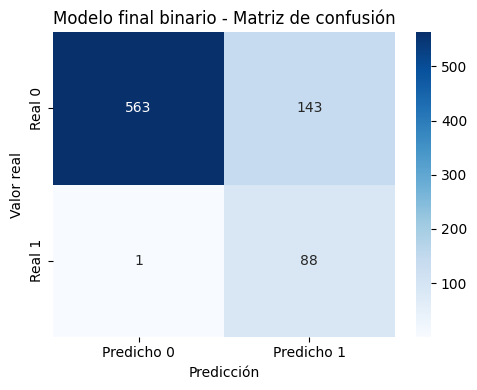

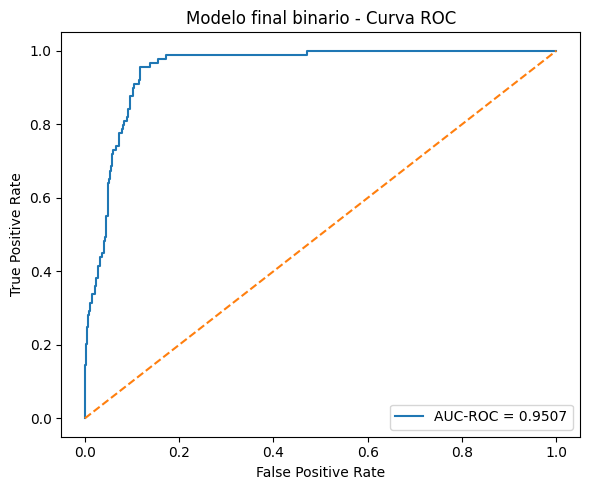

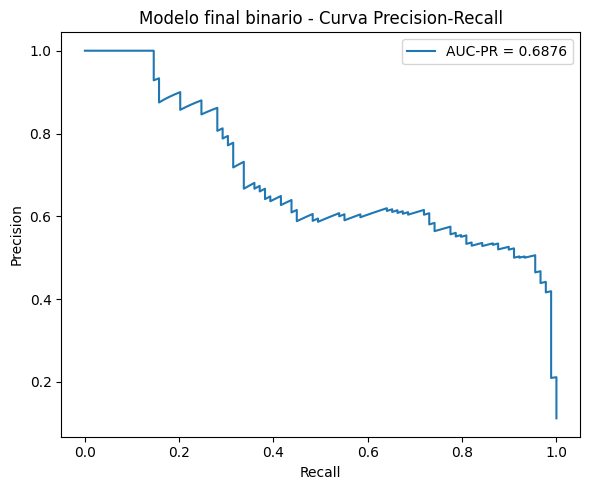

In [54]:
graficar_matriz_confusion(
    resultado_final_binario['matriz_confusion'],
    'Modelo final binario - Matriz de confusión'
)

graficar_curva_roc(
    resultado_final_binario['fpr'],
    resultado_final_binario['tpr'],
    resultado_final_binario['auc_roc'],
    'Modelo final binario - Curva ROC'
)

graficar_curva_pr(
    resultado_final_binario['recall_curve'],
    resultado_final_binario['precision_curve'],
    resultado_final_binario['auc_pr'],
    'Modelo final binario - Curva Precision-Recall'
)

### Matriz de confusión
Muestra lo visto, recupera casi todos los casi todos los casos positivos, con 1 falso negativo nada mas, pero 143 falsos positivos, el modelo prioriza sensibilidad sobre precision. Puede ser razonable si lo que buscamos es no dejar pasar estudiantes insuficientes, al costo de generar algunas alertas incorrectas.

### Curva ROC
La ROC muy por encima de la diagonal aleatoria, la AUC-ROC alcanza 0.951, muy buena capacidad de distinguir globalmente las clases.

### Curva Precision-Recall
La curva Precision-Recall muestra mejor el desempeno sobre la clase positiva, AUC-PR de 0.688 me da algo razonable en el contexto de desbalance, aunque mas moderado que el AUC-ROC, para sostener un recall alto, la precision tiende a bajar.

### Conclusión del caso binario
Puede ser util si queremos detectar la mayor cantidad posible de estudiantes insuficientes, concuerda con todo lo hecho en el inciso 4, la fortaleza es que el recall sea alto, y la debilidad son los falsos positivos.

### Caso multiclase
Para el caso multiclase, reentreno el modelo final seleccionado utilizando los datos de dev y lo evaluo sobre el de test. El pipeline es:
- modelo: Random Forest,
- estrategia de evaluación seleccionada en desarrollo: Group-K-Fold por escuela.

In [55]:
if mejor_modelo_multiclase == 'LDA':
    def model_factory_multiclase_final():
        return LDAClassifierManual(reg_epsilon=1e-6)

elif mejor_modelo_multiclase == 'Logística multiclase':
    def model_factory_multiclase_final():
        return LogisticRegressionMulticlass(
            learning_rate=0.05,
            n_iter=5000,
            lambda_reg=0.1,
            tol=1e-7,
            verbose=False
        )

elif mejor_modelo_multiclase == 'Random Forest':
    def model_factory_multiclase_final():
        return RandomForestClassifierManual(**mejor_config_rf_limpia)

else:
    raise ValueError('Modelo multiclase no reconocido')

In [56]:
resultado_final_multiclase = entrenar_final_y_evaluar_multiclase(
    df_dev=df_multi,
    df_test=df_test,
    model_factory=model_factory_multiclase_final,
    columnas_numericas=columnas_numericas,
    columnas_categoricas=columnas_categoricas,
    target_col='rendimiento',
    categorias_fijas=categorias_fijas,
    class_names=class_names
)

display(resultado_final_multiclase['tabla_por_clase'])
display(resultado_final_multiclase['tabla_resumen'])

,clase,accuracy,precision,recall,f1,auc_roc,auc_pr
0,Insuficiente,0.905660,0.561404,0.719101,0.630542,0.938584,0.645788
1,Regular,0.801258,0.517647,0.536585,0.526946,0.845807,0.486567
2,Bueno,0.773585,0.555024,0.571429,0.563107,0.806783,0.509210
3,Excelente,0.875472,0.897351,0.799410,0.845554,0.954093,0.945099


,accuracy_global,macro_precision,macro_recall,macro_f1,macro_auc_roc,macro_auc_pr
0,0.677987,0.632856,0.656631,0.641537,0.886317,0.646666


El modelo final multiclase alcanza una accuracy de 0.678 y un macro F1 de 0.642, un desempeno solido sobre datos que no fueron vistos. Además, el macro AUC-ROC de 0.886 y el macro AUC-PR de 0.647 nos dice que distingue razonablemente bien a las clases.
Como fue visto en anteriores incisos, el rendimiento por clase es desigual, la clase excelente es la mejor modelada con el mayor F1 y mejores valores de AUC, Insuficiente tambien tiene un desempeno bueno en comparacion con las demas.

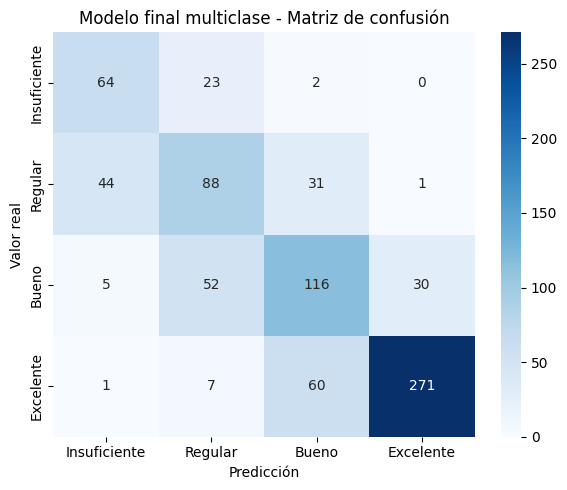

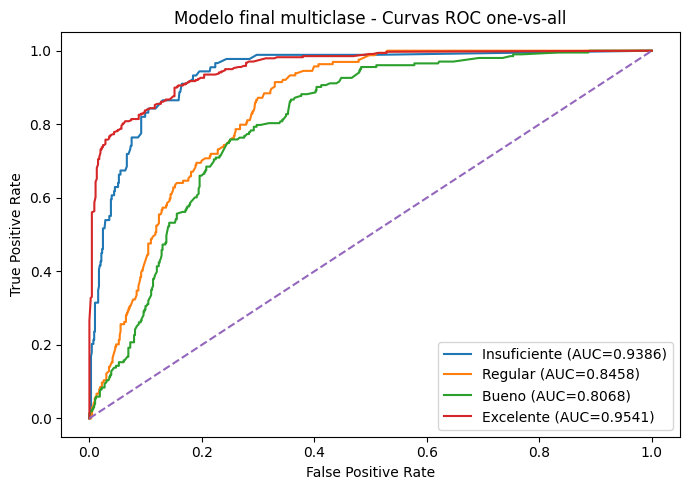

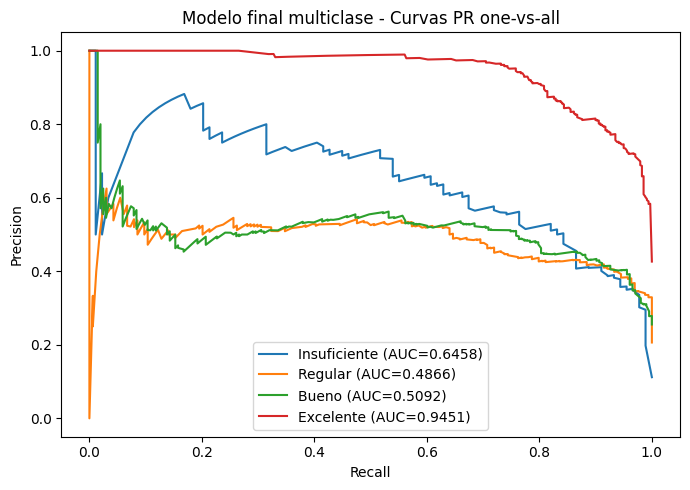

In [57]:
graficar_matriz_confusion_multiclase(
    resultado_final_multiclase['matriz_confusion'],
    class_names,
    'Modelo final multiclase - Matriz de confusión'
)

graficar_roc_multiclase_ovr(
    resultado_final_multiclase['curvas_roc'],
    'Modelo final multiclase - Curvas ROC one-vs-all'
)

graficar_pr_multiclase_ovr(
    resultado_final_multiclase['curvas_pr'],
    'Modelo final multiclase - Curvas PR one-vs-all'
)

### Matriz de confusión del modelo final multiclase
La clase excelente es la mejor reconocida, Insuficiente tambien, aunque algunos casos se confunden con Regular. Regular y Bueno son las mas complicadas para el modelo.

### Curvas ROC one-vs-all
Muestran una buena capacidad de separacion para las clases Excelente e Insuficiente con AUC-ROC altos, Regular es razonable y Bueno la mas complicada. De todos modos es una buena capacidad discriminativa en test.

### Curvas Precision-Recall one-vs-all
Nos dicen mas de lo mismo, Excelente la mejor modelada con curva PR muy superior al resto, la sigue Insuficiente y las otras dos clases se quedan atras.

### Conclusión del caso multiclase
El desempeno en test es consistente con lo observado antes, Random Forest logra algo solido a nivel global y muy bueno par alas clases extremas sobre todo en Excelente. Sigue siendo muy complicado las clases intermedias.


## 5.3 Estimación de cantidad de datos adicionales
En general, tener mas datos suele mejorar la performance de los modelos, aca buscamos estimar cuantas observaciones nuevas harian falta para mejorar solo 1 punto porcentual la accuracy del modelo final multiclase, que fue Random Forest.
Construi una curva de aprendizaje aproximada utilizando distintos tamanos del conjunto de desarrollo y ajusta una relacion entre tamano muestral y accuracy.

In [58]:
tabla_learning_rf, estimacion_rf = estimar_datos_nuevos_random_forest_multiclase(
    df=df_multi,
    rf_params=mejor_config_rf_limpia,
    columnas_numericas=columnas_numericas,
    columnas_categoricas=columnas_categoricas,
    target_col='rendimiento',
    group_col='escuela',
    categorias_fijas=categorias_fijas,
    class_names=class_names,
    fracciones=[0.4, 0.55, 0.7, 0.85, 1.0],
    n_splits=4,
    random_state=42,
    incremento_objetivo=0.01
)

display(tabla_learning_rf)
estimacion_rf

,fraccion,n_muestras,accuracy
0,0.40,2020,0.541584
1,0.55,2779,0.527168
2,0.70,3537,0.551032
3,0.85,4296,0.552142
4,1.00,5058,0.573151


{'pendiente': np.float64(-3.7770849571997487),
 'intercepto': np.float64(0.6150021687773489),
 'accuracy_actual': np.float64(0.5731514432582048),
 'accuracy_objetivo': np.float64(0.5831514432582048),
 'n_actual': np.float64(5058.0),
 'n_estimado_total': np.float64(14062.89868534158),
 'datos_nuevos_estimados': np.float64(9004.89868534158)}

Esta tabla nos deja ver que en general al aumentar la cantidad de muestras la accuracy tiende a mejorar, igualmente no es una relacion monotona, aparecen oscilaciones, por lo que la curva de aprendizaje es razonable como aproximacion, no para interpretarla de forma exacta.

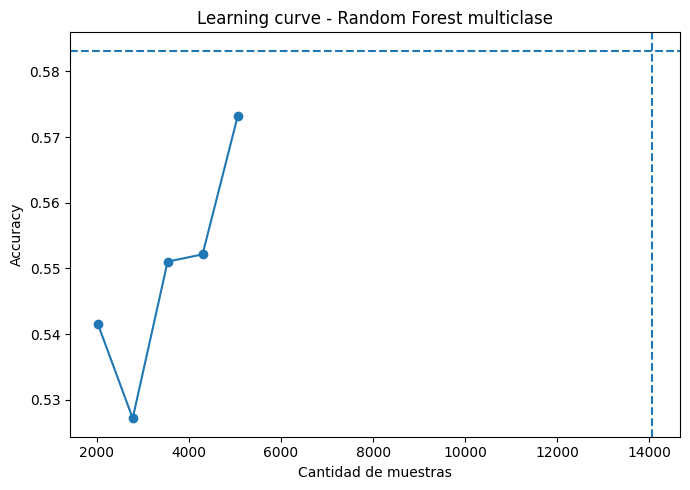

In [59]:
graficar_learning_curve_rf(
    tabla_learning_rf,
    estimacion=estimacion_rf,
    titulo='Learning curve - Random Forest multiclase'
)

### Estimación visual
Con la curva y el ajuste hecho se estima la cantidad total de muestras necesarias para alcanzar una accuracy 1% mejor a la actual, el model oparte de una accuracy estimada de 0.5732 con 5058 muestras, entonces se busca alcanzar aproximadamente 0.5832 de accuracy.


In [60]:
if pd.isna(estimacion_rf['datos_nuevos_estimados']):
    print('No se pudo obtener una estimación estable para lograr +1% de accuracy con el ajuste usado.')
else:
    print('Accuracy actual estimada:', round(estimacion_rf['accuracy_actual'], 4))
    print('Accuracy objetivo:', round(estimacion_rf['accuracy_objetivo'], 4))
    print('Cantidad actual de datos:', int(estimacion_rf['n_actual']))
    print('Cantidad total estimada necesaria:', int(np.ceil(estimacion_rf['n_estimado_total'])))
    print('Datos nuevos estimados a agregar:', int(np.ceil(estimacion_rf['datos_nuevos_estimados'])))

Accuracy actual estimada: 0.5732
Accuracy objetivo: 0.5832
Cantidad actual de datos: 5058
Cantidad total estimada necesaria: 14063
Datos nuevos estimados a agregar: 9005


### Resultado de la estimación
Segun la extrapolacion hecha, faltarian 14063 observaciones mas lo que implica agregar 9005 datos nuevos respecto al conjunto actual, para mejorar solo un 1% la accuracy del Random Forest multiclase, seria necesario casi que triplicar el tamano actual del conjunto dev.

### Limitaciones de la estimación
Como dije hay que interpretar con cuidado esta estimacion, la curva de aprendizaje se construyo con pocos puntos y se ve poco variabilidad, es solo una aproximacion. No hay que pensar que exactamente 9005 datos nuevos garanticen una mejora del 1% de accuracy, pero que si se necesita algo de esa magnitud, mucho.



### Conclusión
Como conlusion, no es para nada sencillo mejorar el accuracy de este modelo, incluso bajo una extrapolacion optimista, faltan muchas observaciones nuevas. Esto me dice que a partir del performance actual, seguir ganando accuracy solo por aumentar el tamano de la muestra, puede tener rendimientos decrecientes.